In [ ]:
import zipfile
import os

# Path to the ZIP file
zip_path = "/content/drive/MyDrive/maizedata.zip"

# Destination folder for extraction
extract_to = "/content/drive/MyDrive/Corn"

# Create the destination folder if it doesn't exist
os.makedirs(extract_to, exist_ok=True)

# Extract the ZIP file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)
print("ZIP file extracted successfully!")


ZIP file extracted successfully!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

def count_images_in_folder(root_dir):
    total_images = 0
    for subdir, _, files in os.walk(root_dir):
        image_files = [file for file in files if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff'))]
        total_images += len(image_files)
    return total_images

# Set the path to your main folder
root_directory = "/content/drive/MyDrive/Corn/data"

# Count total images
total_images = count_images_in_folder(root_directory)
print(f"Total number of images: {total_images}")


Total number of images: 4188


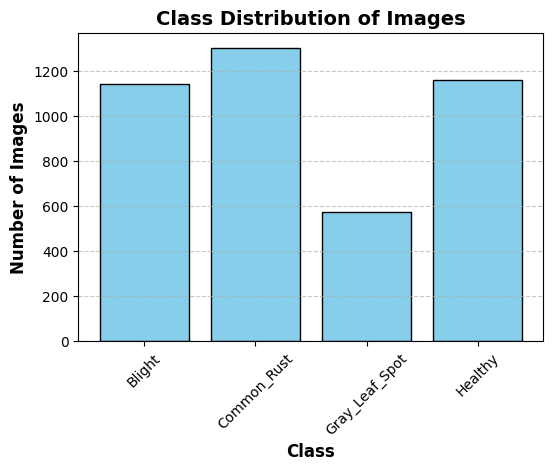

In [ ]:
import os
import matplotlib.pyplot as plt
from collections import Counter

# Path to the main dataset folder containing subfolders
dataset_path = "/content/drive/MyDrive/Corn/data"

# List all subfolders (classes)
classes = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]

# Dictionary to store the count of images per class
class_distribution = Counter()

# Count the number of images in each class
for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)
    num_images = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    class_distribution[class_name] = num_images

# Plot the class distribution
plt.figure(figsize=(6, 4))
plt.bar(class_distribution.keys(), class_distribution.values(), color='skyblue', edgecolor='black')

# Labeling
plt.xlabel("Class", fontsize=12, fontweight='bold')
plt.ylabel("Number of Images", fontsize=12, fontweight='bold')
plt.title("Class Distribution of Images", fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()

In [ ]:
pip install split-folders

In [ ]:
import splitfolders

input_folder = "/content/drive/MyDrive/Corn/data"
output_folder = "/content/drive/MyDrive/CornSplit"

splitfolders.ratio(input_folder, output=output_folder, seed=42, ratio=(0.75, 0.15, 0.10), group_prefix=None, move=False)


Copying files: 4188 files [01:12, 57.76 files/s]


# VGG16


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define dataset directories
train_dir = "/content/drive/MyDrive/CornSplit/train"
val_dir = "/content/drive/MyDrive/CornSplit/val"
test_dir = "/content/drive/MyDrive/CornSplit/test"

# Define ImageDataGenerators for data loading and augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=20, width_shift_range=0.2, height_shift_range=0.2, horizontal_flip=True
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Set batch size and image size
batch_size = 32
img_size = (224, 224)

# Load images from directories
train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=True
)
val_generator = val_test_datagen.flow_from_directory(
    val_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=False
)
test_generator = val_test_datagen.flow_from_directory(
    test_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=False
)

# Load VGG16 model without the classification head
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Set base model trainability (can be True or False)
base_model.trainable = True  # Set to False to freeze the convolutional layers

# Add custom layers on top of VGG16
x = GlobalAveragePooling2D()(base_model.output)  # Fix the layer connection
x = Dense(128, activation='relu')(x)  # Fully connected layer
x = Dense(len(train_generator.class_indices), activation='softmax')(x)  # Output layer with softmax

# Create final model
model = Model(inputs=base_model.input, outputs=x)

# Compile model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

# Callbacks for early stopping and saving best model
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint("/content/drive/MyDrive/AfriModels/vgg16_best_model.h5", save_best_only=True, monitor='val_accuracy')

# Train model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=[early_stop, checkpoint]
)

# Save the final model
model.save("/content/drive/MyDrive/AfriModels/vgg16_final_model.h5")


Found 3139 images belonging to 4 classes.
Found 626 images belonging to 4 classes.
Found 423 images belonging to 4 classes.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │          65,6

 Total params: 14,780,868 (56.38 MB)

 Trainable params: 14,780,868 (56.38 MB)

...

99/99 ━━━━━━━━━━━━━━━━━━━━ 70s 698ms/step - accuracy: 0.8513 - loss: 0.3469 - val_accuracy: 0.8962 - val_loss: 0.2465
Epoch 3/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 639ms/step - accuracy: 0.8998 - loss: 0.2694

99/99 ━━━━━━━━━━━━━━━━━━━━ 71s 704ms/step - accuracy: 0.8999 - loss: 0.2692 - val_accuracy: 0.9217 - val_loss: 0.1919
Epoch 4/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 68s 674ms/step - accuracy: 0.9163 - loss: 0.2224 - val_accuracy: 0.9217 - val_loss: 0.2032
Epoch 5/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 627ms/step - accuracy: 0.9350 - loss: 0.1782

99/99 ━━━━━━━━━━━━━━━━━━━━ 69s 692ms/step - accuracy: 0.9349 - loss: 0.1782 - val_accuracy: 0.9441 - val_loss: 0.1365
Epoch 6/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 634ms/step - accuracy: 0.9426 - loss: 0.1568

99/99 ━━━━━━━━━━━━━━━━━━━━ 72s 714ms/step - accuracy: 0.9426 - loss: 0.1569 - val_accuracy: 0.9457 - val_loss: 0.1393
Epoch 7/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 76s 672ms/step - accuracy: 0.9482 - loss: 0.1508 - val_accuracy: 0.9089 - val_loss: 0.2063
Epoch 8/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 67s 670ms/step - accuracy: 0.9513 - loss: 0.1417 - val_accuracy: 0.9393 - val_loss: 0.1365
Epoch 9/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 66s 660ms/step - accuracy: 0.9589 - loss: 0.1087 - val_accuracy: 0.9441 - val_loss: 0.1403
Epoch 10/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 634ms/step - accuracy: 0.9446 - loss: 0.1372

99/99 ━━━━━━━━━━━━━━━━━━━━ 71s 714ms/step - accuracy: 0.9446 - loss: 0.1371 - val_accuracy: 0.9505 - val_loss: 0.1306
Epoch 11/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 68s 686ms/step - accuracy: 0.9514 - loss: 0.1356 - val_accuracy: 0.9329 - val_loss: 0.1767
Epoch 12/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 69s 694ms/step - accuracy: 0.9583 - loss: 0.1165 - val_accuracy: 0.9361 - val_loss: 0.1820
Epoch 13/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 68s 681ms/step - accuracy: 0.9554 - loss: 0.1238 - val_accuracy: 0.9457 - val_loss: 0.1398
Epoch 14/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 67s 678ms/step - accuracy: 0.9634 - loss: 0.1063 - val_accuracy: 0.9505 - val_loss: 0.1671
Epoch 15/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 67s 673ms/step - accuracy: 0.9615 - loss: 0.1140 - val_accuracy: 0.9505 - val_loss: 0.1471


In [ ]:
model.save("/content/drive/MyDrive/Maize/VGG16maize.h5")

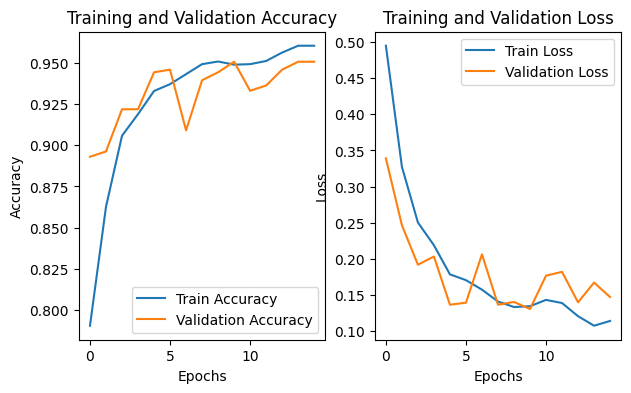

In [ ]:
plt.figure(figsize=(7, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()


14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 182ms/step
                precision    recall  f1-score   support

        Blight       0.93      0.91      0.92       116
   Common_Rust       0.97      1.00      0.99       132
Gray_Leaf_Spot       0.84      0.83      0.83        58
       Healthy       1.00      1.00      1.00       117

      accuracy                           0.95       423
     macro avg       0.94      0.93      0.93       423
  weighted avg       0.95      0.95      0.95       423



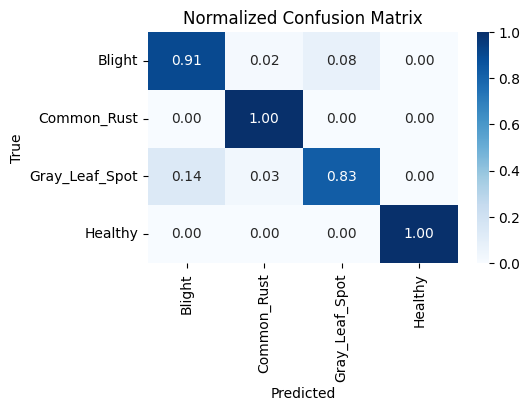

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Get true labels and predictions
test_generator.reset()
y_true = test_generator.classes
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
class_labels = list(test_generator.class_indices.keys())

# Classification report
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

# Compute Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Normalize confusion matrix between 0 and 1
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

# Plot normalized Confusion Matrix
plt.figure(figsize=(5, 3))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Normalized Confusion Matrix')
plt.show()


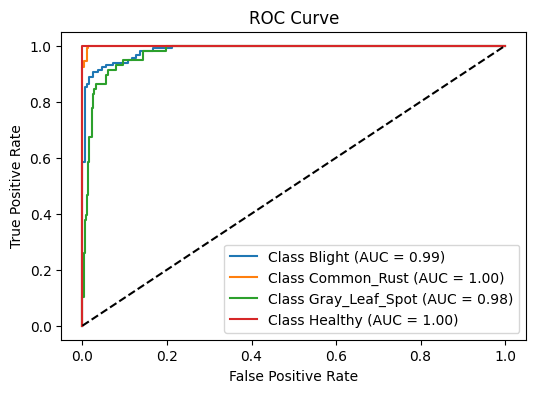

In [ ]:
from sklearn.preprocessing import label_binarize

# Convert labels to one-hot encoding
y_true_bin = label_binarize(y_true, classes=np.arange(len(class_labels)))
n_classes = y_true_bin.shape[1]

# Compute ROC curve and ROC area for each class
plt.figure(figsize=(6, 4))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {class_labels[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


#test the model

In [ ]:
# Evaluate the model on the test dataset
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 215ms/step - accuracy: 0.9374 - loss: 0.2122
Test Accuracy: 0.9504
Test Loss: 0.1642


# ResNet50

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define dataset directories
train_dir = "/content/drive/MyDrive/CornSplit/train"
val_dir = "/content/drive/MyDrive/CornSplit/val"
test_dir = "/content/drive/MyDrive/CornSplit/test"

# Define ImageDataGenerators for data loading and augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=20, width_shift_range=0.2, height_shift_range=0.2, horizontal_flip=True
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Set batch size and image size
batch_size = 32
img_size = (224, 224)  # ResNet50 uses 224x224 input size

# Load images from directories
train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=True
)
val_generator = val_test_datagen.flow_from_directory(
    val_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=False
)
test_generator = val_test_datagen.flow_from_directory(
    test_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=False
)

# Load the pre-trained ResNet50 model (without the top layer)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Set base model trainability (can be True or False)
base_model.trainable = False  # Set to False to freeze the convolutional layers

# Add custom layers on top of ResNet50
x = GlobalAveragePooling2D()(base_model.output)  # Fix the layer connection
x = Dense(128, activation='relu')(x)  # Fully connected layer
x = Dense(len(train_generator.class_indices), activation='softmax')(x)  # Output layer with softmax

# Create final model
model = Model(inputs=base_model.input, outputs=x)

# Compile model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

# Callbacks for early stopping and saving best model
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint("/content/drive/MyDrive/AfriModels/resnet50_best_model.h5", save_best_only=True, monitor='val_accuracy')

# Train model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=[early_stop, checkpoint]
)

# Save the final model
model.save("/content/drive/MyDrive/AfriModels/resnet50_final_model.h5")


Found 3139 images belonging to 4 classes.
Found 626 images belonging to 4 classes.
Found 423 images belonging to 4 classes.


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 230, 230, 3)    │              0 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 112, 112, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 114, 114, 64)   │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 56, 56, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 56, 56, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 56, 56, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)             

 Total params: 23,850,500 (90.98 MB)

 Trainable params: 262,788 (1.00 MB)

...

99/99 ━━━━━━━━━━━━━━━━━━━━ 84s 557ms/step - accuracy: 0.6418 - loss: 0.9199 - val_accuracy: 0.6773 - val_loss: 0.8270
Epoch 35/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 53s 536ms/step - accuracy: 0.6259 - loss: 0.9304 - val_accuracy: 0.6534 - val_loss: 0.8247
Epoch 36/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 81s 531ms/step - accuracy: 0.6382 - loss: 0.8948 - val_accuracy: 0.6502 - val_loss: 0.8382
Epoch 37/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step - accuracy: 0.6365 - loss: 0.9061

99/99 ━━━━━━━━━━━━━━━━━━━━ 84s 549ms/step - accuracy: 0.6365 - loss: 0.9061 - val_accuracy: 0.6949 - val_loss: 0.8216
Epoch 38/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 80s 534ms/step - accuracy: 0.6439 - loss: 0.9238 - val_accuracy: 0.6597 - val_loss: 0.8063
Epoch 39/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 53s 534ms/step - accuracy: 0.6280 - loss: 0.9131 - val_accuracy: 0.6901 - val_loss: 0.8245
Epoch 40/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step - accuracy: 0.6437 - loss: 0.9023

99/99 ━━━━━━━━━━━━━━━━━━━━ 83s 549ms/step - accuracy: 0.6438 - loss: 0.9021 - val_accuracy: 0.6997 - val_loss: 0.7990
Epoch 41/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 80s 534ms/step - accuracy: 0.6373 - loss: 0.8929 - val_accuracy: 0.6597 - val_loss: 0.8297
Epoch 42/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 82s 536ms/step - accuracy: 0.6420 - loss: 0.8922 - val_accuracy: 0.6933 - val_loss: 0.7937
Epoch 43/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 53s 536ms/step - accuracy: 0.6618 - loss: 0.8695 - val_accuracy: 0.6645 - val_loss: 0.8309
Epoch 44/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 55s 551ms/step - accuracy: 0.6427 - loss: 0.8814 - val_accuracy: 0.6757 - val_loss: 0.7943
Epoch 45/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 53s 534ms/step - accuracy: 0.6438 - loss: 0.8935 - val_accuracy: 0.6805 - val_loss: 0.7861
Epoch 46/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 523ms/step - accuracy: 0.6497 - loss: 0.8551

99/99 ━━━━━━━━━━━━━━━━━━━━ 59s 592ms/step - accuracy: 0.6497 - loss: 0.8552 - val_accuracy: 0.7125 - val_loss: 0.8060
Epoch 47/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 54s 545ms/step - accuracy: 0.6545 - loss: 0.8614 - val_accuracy: 0.6853 - val_loss: 0.7747
Epoch 48/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 81s 539ms/step - accuracy: 0.6456 - loss: 0.8679 - val_accuracy: 0.6917 - val_loss: 0.7796
Epoch 49/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 512ms/step - accuracy: 0.6600 - loss: 0.8456

99/99 ━━━━━━━━━━━━━━━━━━━━ 85s 566ms/step - accuracy: 0.6600 - loss: 0.8457 - val_accuracy: 0.7188 - val_loss: 0.7696
Epoch 50/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 55s 550ms/step - accuracy: 0.6488 - loss: 0.8643 - val_accuracy: 0.6949 - val_loss: 0.7798


In [ ]:
model.save("/content/drive/MyDrive/Maize/ResNet50.h5")

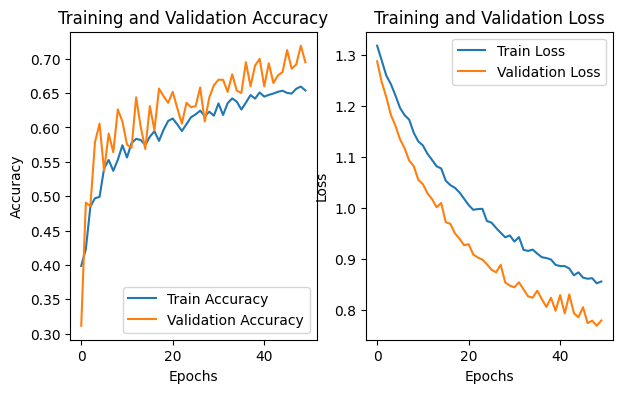

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


14/14 ━━━━━━━━━━━━━━━━━━━━ 122s 9s/step
                precision    recall  f1-score   support

        Blight       0.56      0.61      0.59       116
   Common_Rust       0.89      0.93      0.91       132
Gray_Leaf_Spot       0.55      0.28      0.37        58
       Healthy       0.72      0.79      0.75       117

      accuracy                           0.72       423
     macro avg       0.68      0.65      0.65       423
  weighted avg       0.71      0.72      0.70       423



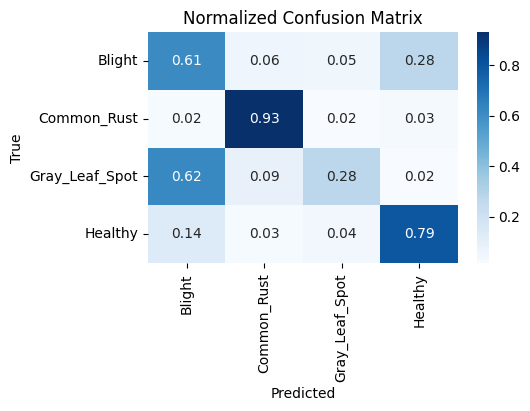

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Get true labels and predictions
test_generator.reset()
y_true = test_generator.classes
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
class_labels = list(test_generator.class_indices.keys())

# Classification report
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

# Compute Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Normalize confusion matrix between 0 and 1
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

# Plot normalized Confusion Matrix
plt.figure(figsize=(5, 3))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Normalized Confusion Matrix')
plt.show()


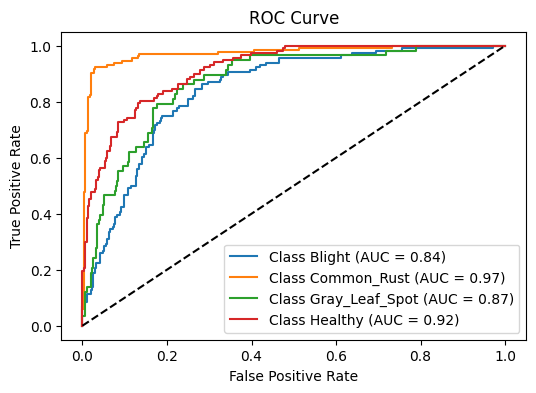

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# Convert labels to one-hot encoding
y_true_bin = label_binarize(y_true, classes=np.arange(len(class_labels)))
n_classes = y_true_bin.shape[1]

# Compute ROC curve and ROC area for each class
plt.figure(figsize=(6, 4))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {class_labels[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


In [ ]:
# Evaluate the model on the test dataset
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 264ms/step - accuracy: 0.6763 - loss: 0.7999
Test Accuracy: 0.7163
Test Loss: 0.7555


# ensemble prediction

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Flatten, Concatenate, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import numpy as np

# Define dataset directories
train_dir = "/content/drive/MyDrive/CornSplit/train"
val_dir = "/content/drive/MyDrive/CornSplit/val"
test_dir = "/content/drive/MyDrive/CornSplit/test"

# Define ImageDataGenerators
train_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=20, width_shift_range=0.2, height_shift_range=0.2, horizontal_flip=True
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Set batch size and image size
batch_size = 32
img_size = (224, 224)  # Standard input size for VGG16, ResNet50, and AlexNet

# Load images from directories
train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=True
)
val_generator = val_test_datagen.flow_from_directory(
    val_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=False
)
test_generator = val_test_datagen.flow_from_directory(
    test_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=False
)

# Load pre-trained models (without top layers)
vgg16_base = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
resnet50_base = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# AlexNet (Custom Implementation in Keras)
def AlexNet(input_shape=(224, 224, 3)):
    inputs = Input(shape=input_shape)
    x = tf.keras.layers.Conv2D(96, (11, 11), strides=4, activation='relu')(inputs)
    x = tf.keras.layers.MaxPooling2D((3, 3), strides=2)(x)
    x = tf.keras.layers.Conv2D(256, (5, 5), padding='same', activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D((3, 3), strides=2)(x)
    x = tf.keras.layers.Conv2D(384, (3, 3), padding='same', activation='relu')(x)
    x = tf.keras.layers.Conv2D(384, (3, 3), padding='same', activation='relu')(x)
    x = tf.keras.layers.Conv2D(256, (3, 3), padding='same', activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D((3, 3), strides=2)(x)
    x = Flatten()(x)
    model = Model(inputs, x, name="AlexNet")
    return model

alexnet_base = AlexNet()

# Freeze base models
vgg16_base.trainable = True
resnet50_base.trainable = False
alexnet_base.trainable = False

# Extract features
vgg16_features = GlobalAveragePooling2D()(vgg16_base.output)
resnet50_features = GlobalAveragePooling2D()(resnet50_base.output)
alexnet_features = alexnet_base.output  # Already flattened

# Concatenate features
merged = Concatenate()([vgg16_features, resnet50_features, alexnet_features])

# Fully connected layers
x = Dense(256, activation='relu')(merged)
x = Dense(128, activation='relu')(x)
out = Dense(len(train_generator.class_indices), activation='softmax')(x)

# Create final model with three inputs
ensemble_model = Model(inputs=[vgg16_base.input, resnet50_base.input, alexnet_base.input], outputs=out)

# Compile model
ensemble_model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# Print model summary
ensemble_model.summary()

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint("/content/drive/MyDrive/Maize/ensemble_final_model.h5", save_best_only=True, monitor='val_accuracy')

# Custom data generator to replicate the inputs for each model branch
def multi_input_generator(generator):
    while True:
        batch_x, batch_y = next(generator)  # Get a batch of images and labels
        # Provide the same input to all three model branches as a tuple (not list)
        yield (batch_x, batch_x, batch_x), batch_y

# Wrap the existing generators
train_multi_generator = multi_input_generator(train_generator)
val_multi_generator = multi_input_generator(val_generator)
test_multi_generator = multi_input_generator(test_generator)

# Train model
history = ensemble_model.fit(
    train_multi_generator,
    validation_data=val_multi_generator,
    steps_per_epoch=len(train_generator),
    validation_steps=len(val_generator),
    epochs=50,
    callbacks=[early_stop, checkpoint]
)

# Save final model
ensemble_model.save("/content/drive/MyDrive/Maize/ensemble_final_model.h5")


Found 3139 images belonging to 4 classes.
Found 626 images belonging to 4 classes.
Found 423 images belonging to 4 classes.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 230, 230, 3)    │              0 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 112, 112, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 114, 114, 64)   │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 56, 56, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 56, 56, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 56, 56, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)             

 Total params: 44,377,028 (169.28 MB)

 Trainable params: 17,042,116 (65.01 MB)

...

99/99 ━━━━━━━━━━━━━━━━━━━━ 88s 895ms/step - accuracy: 0.9285 - loss: 0.1774 - val_accuracy: 0.9441 - val_loss: 0.1715
Epoch 13/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 68s 683ms/step - accuracy: 0.9390 - loss: 0.1635 - val_accuracy: 0.9121 - val_loss: 0.2290
Epoch 14/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 71s 723ms/step - accuracy: 0.9307 - loss: 0.1689 - val_accuracy: 0.9377 - val_loss: 0.1722
Epoch 15/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 83s 844ms/step - accuracy: 0.9532 - loss: 0.1309 - val_accuracy: 0.9425 - val_loss: 0.1822
Epoch 16/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 557ms/step - accuracy: 0.9569 - loss: 0.1107

99/99 ━━━━━━━━━━━━━━━━━━━━ 71s 716ms/step - accuracy: 0.9569 - loss: 0.1108 - val_accuracy: 0.9457 - val_loss: 0.1407
Epoch 17/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 666ms/step - accuracy: 0.9500 - loss: 0.1335

99/99 ━━━━━━━━━━━━━━━━━━━━ 82s 829ms/step - accuracy: 0.9500 - loss: 0.1335 - val_accuracy: 0.9489 - val_loss: 0.1430
Epoch 18/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 658ms/step - accuracy: 0.9539 - loss: 0.1157

99/99 ━━━━━━━━━━━━━━━━━━━━ 90s 913ms/step - accuracy: 0.9539 - loss: 0.1157 - val_accuracy: 0.9537 - val_loss: 0.1515
Epoch 19/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 671ms/step - accuracy: 0.9569 - loss: 0.1240

99/99 ━━━━━━━━━━━━━━━━━━━━ 82s 835ms/step - accuracy: 0.9569 - loss: 0.1240 - val_accuracy: 0.9569 - val_loss: 0.1606
Epoch 20/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - accuracy: 0.9555 - loss: 0.1289 - val_accuracy: 0.9281 - val_loss: 0.1771
Epoch 21/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 82s 832ms/step - accuracy: 0.9414 - loss: 0.1474 - val_accuracy: 0.9505 - val_loss: 0.1498


In [ ]:
ensemble_model.save("/content/drive/MyDrive/Maize/ensemble_final_model.h5")

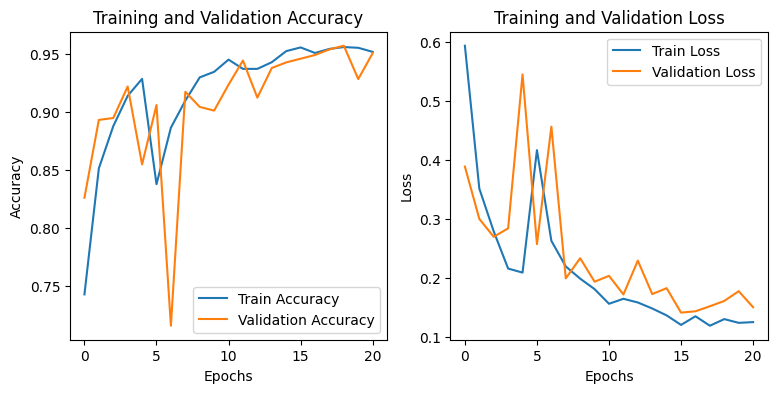

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
plt.figure(figsize=(9, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Get true labels and predictions
test_generator.reset()
y_true = test_generator.classes
y_pred = ensemble_model.predict(test_multi_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
class_labels = list(test_generator.class_indices.keys())

# Classification report
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

# Compute Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Normalize confusion matrix between 0 and 1
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

# Plot normalized Confusion Matrix
plt.figure(figsize=(5, 3))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Normalized Confusion Matrix')
plt.show()

   3915/Unknown 1364s 347ms/step

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# Convert labels to one-hot encoding
y_true_bin = label_binarize(y_true, classes=np.arange(len(class_labels)))
n_classes = y_true_bin.shape[1]

# Compute ROC curve and ROC area for each class
plt.figure(figsize=(6, 4))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {class_labels[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [ ]:
# Evaluate the model on the test dataset
test_loss, test_accuracy = ensemble_model.evaluate(test_multi_generator)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

NameError: name 'ensemble_model' is not defined

In [ ]:
pip install kivy kivymd tensorflow numpy pillow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 30.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.0/23.0 MB 37.4 MB/s eta 0:00:00
  Created wheel for kivymd: filename=kivymd-1.2.0-py3-none-any.whl size=2235583 sha256=59b96dd02fb8f6ea6a7bc4c7c6d9ce515ab6093f02fd0dc09387c1082e1af03d
  Stored in directory: /root/.cache/pip/wheels/13/24/31/a90ecea1a8579d11a9c290c2b91f0b63d39ca9042da54b8d76
Successfully built kivymd


In [ ]:
pip install kivy


In [ ]:
!python test.py

python3: can't open file '/content/test.py': [Errno 2] No such file or directory


OSError: source code not available

In [ ]:
from kivy.lang import Builder
from kivy.uix.image import Image
from kivy.uix.boxlayout import BoxLayout
from kivy.uix.button import Button
from kivy.uix.label import Label
from kivy.uix.filechooser import FileChooserIconView
from kivy.graphics.texture import Texture
from kivy.app import App
from kivy.clock import mainthread
from kivymd.uix.button import MDRaisedButton
import tensorflow as tf
import numpy as np
from PIL import Image as PILImage

# Load the trained model
MODEL_PATH = "/content/drive/MyDrive/Maize/AlexNetMaize.h5"  # Change to your model filename
model = tf.keras.models.load_model(MODEL_PATH)

# Define image size based on the model input
IMG_SIZE = (224, 224)  # Change according to your model input shape


class MaizeDiseaseApp(App):
    # Assign KV language string to the kv attribute
    kv = """
BoxLayout:
    orientation: 'vertical'
    canvas.before:
        Color:
            rgba: 0.5, 0.5, 1, 1
        Rectangle:
            pos: self.pos
            size: self

SyntaxError: incomplete input (<ipython-input-6-22808da02d4d>, line 25)

In [ ]:
from google.colab import files
import tensorflow as tf
import numpy as np
from PIL import Image as PILImage
import datetime
import io

# Load the trained model
MODEL_PATH = "/content/drive/MyDrive/Maize/AlexNetMaize.h5"
try:
    model = tf.keras.models.load_model(MODEL_PATH)
    print("Model loaded successfully!")
except Exception as e:
    print(f"Error loading model: {e}")

# Define image size based on the model input
IMG_SIZE = (224, 224)

def upload_and_predict():
    """Uploads an image, preprocesses it, and runs classification."""
    uploaded = files.upload()
    for filename in uploaded.keys():
        try:
            # Open the uploaded image
            pil_image = PILImage.open(io.BytesIO(uploaded[filename])).resize(IMG_SIZE)

            # Preprocess the image
            img_array = np.array(pil_image) / 255.0
            img_array = np.expand_dims(img_array, axis=0)

            # Run prediction
            predictions = model.predict(img_array)
            predicted_class = np.argmax(predictions)
            confidence = np.max(predictions) * 100
            scan_date = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")

            # Display results
            print(f"Predicted Disease Type: {predicted_class}")
            print(f"Confidence: {confidence:.2f}%")
            print(f"Scan Date: {scan_date}")

            # Display image
            pil_image.show()
        except Exception as e:
            print(f"Error processing image: {e}")

# Run the function to upload and classify an image
upload_and_predict()

Model loaded successfully!


In [ ]:
import tensorflow as tf

In [ ]:
model=tf.keras.models.load_model('/content/drive/MyDrive/Maize/VGG16maize.h5')
converter = tf.tf.lite.TFLiteConverter.from_keras_model(model)

In [ ]:
import tensorflow as tf

# Load the .h5 model
h5_model_path = "/content/drive/MyDrive/Maize/VGG16maize.h5"  # Change this to your model's path
model = tf.keras.models.load_model(h5_model_path)

# Convert the model to TensorFlow Lite format
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the .tflite model
tflite_model_path = "/content/drive/MyDrive/Maize/VGG16model.tflite"
with open(tflite_model_path, "wb") as f:
    f.write(tflite_model)

print(f"Model successfully converted and saved as {tflite_model_path}")


Saved artifact at '/tmp/tmp18gra0w3'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_2')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  140021791027472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140021791028048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140021791028240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140021791027856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140021791029200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140021791024784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140021791028816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140021791028432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140021791030736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140021791030160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1400217910311

# VGG16 without data augmentation

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define dataset directories
train_dir = "/content/drive/MyDrive/CornSplit/train"
val_dir = "/content/drive/MyDrive/CornSplit/val"
test_dir = "/content/drive/MyDrive/CornSplit/test"

# Define ImageDataGenerators for data loading and augmentation
train_datagen = ImageDataGenerator(
)
val_test_datagen = ImageDataGenerator()

# Set batch size and image size
batch_size = 32
img_size = (224, 224)

# Load images from directories
train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=True
)
val_generator = val_test_datagen.flow_from_directory(
    val_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=False
)
test_generator = val_test_datagen.flow_from_directory(
    test_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=False
)

# Load VGG16 model without the classification head
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Set base model trainability (can be True or False)
base_model.trainable = True  # Set to False to freeze the convolutional layers

# Add custom layers on top of VGG16
x = GlobalAveragePooling2D()(base_model.output)  # Fix the layer connection
x = Dense(128, activation='relu')(x)  # Fully connected layer
x = Dense(len(train_generator.class_indices), activation='softmax')(x)  # Output layer with softmax

# Create final model
model = Model(inputs=base_model.input, outputs=x)

# Compile model
model.compile(optimizer=Adam(learning_rate=0.00001), loss='categorical_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

# Callbacks for early stopping and saving best model
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint("/content/drive/MyDrive/AfriModels/vgg16_best_model.h5", save_best_only=True, monitor='val_accuracy')

# Train model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=[early_stop, checkpoint]
)

# Save the final model
model.save("/content/drive/MyDrive/AfriModels/vgg16_final_model2.h5")


Found 3139 images belonging to 4 classes.
Found 626 images belonging to 4 classes.
Found 423 images belonging to 4 classes.


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,868 (56.38 MB)

 Trainable params: 14,780,868 (56.38 MB)

...

99/99 ━━━━━━━━━━━━━━━━━━━━ 57s 579ms/step - accuracy: 0.9405 - loss: 0.1731 - val_accuracy: 0.9169 - val_loss: 0.2401
Epoch 3/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step - accuracy: 0.9775 - loss: 0.0757

99/99 ━━━━━━━━━━━━━━━━━━━━ 56s 565ms/step - accuracy: 0.9775 - loss: 0.0757 - val_accuracy: 0.9297 - val_loss: 0.2374
Epoch 4/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 509ms/step - accuracy: 0.9863 - loss: 0.0452

99/99 ━━━━━━━━━━━━━━━━━━━━ 58s 585ms/step - accuracy: 0.9863 - loss: 0.0452 - val_accuracy: 0.9425 - val_loss: 0.2175
Epoch 5/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 54s 549ms/step - accuracy: 0.9742 - loss: 0.0646 - val_accuracy: 0.9425 - val_loss: 0.2490
Epoch 6/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.9918 - loss: 0.0240

99/99 ━━━━━━━━━━━━━━━━━━━━ 53s 535ms/step - accuracy: 0.9919 - loss: 0.0240 - val_accuracy: 0.9441 - val_loss: 0.2455
Epoch 7/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 505ms/step - accuracy: 0.9996 - loss: 0.0051

99/99 ━━━━━━━━━━━━━━━━━━━━ 57s 575ms/step - accuracy: 0.9995 - loss: 0.0051 - val_accuracy: 0.9457 - val_loss: 0.2470
Epoch 8/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 56s 563ms/step - accuracy: 0.9993 - loss: 0.0079 - val_accuracy: 0.9457 - val_loss: 0.2427
Epoch 9/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 51s 515ms/step - accuracy: 0.9999 - loss: 0.0028 - val_accuracy: 0.9457 - val_loss: 0.2853


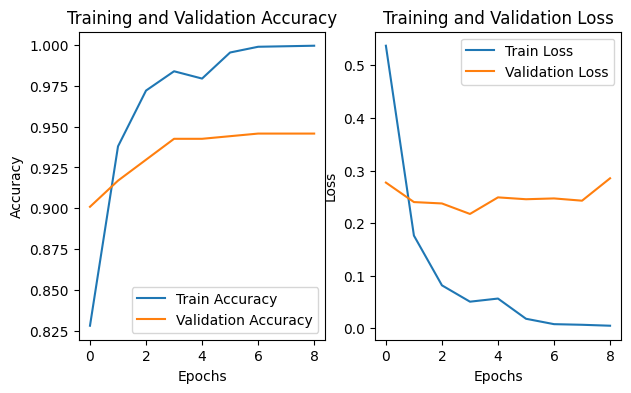

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


14/14 ━━━━━━━━━━━━━━━━━━━━ 146s 11s/step
                precision    recall  f1-score   support

        Blight       0.88      0.85      0.87       116
   Common_Rust       0.95      0.96      0.95       132
Gray_Leaf_Spot       0.75      0.76      0.75        58
       Healthy       0.99      1.00      1.00       117

      accuracy                           0.91       423
     macro avg       0.89      0.89      0.89       423
  weighted avg       0.91      0.91      0.91       423



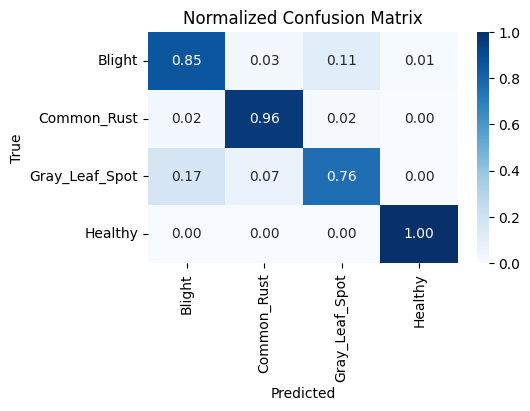

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Get true labels and predictions
test_generator.reset()
y_true = test_generator.classes
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
class_labels = list(test_generator.class_indices.keys())

# Classification report
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

# Compute Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Normalize confusion matrix between 0 and 1
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

# Plot normalized Confusion Matrix
plt.figure(figsize=(5, 3))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Normalized Confusion Matrix')
plt.show()


#ResNet50 without Data Augmentation

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define dataset directories
train_dir = "/content/drive/MyDrive/CornSplit/train"
val_dir = "/content/drive/MyDrive/CornSplit/val"
test_dir = "/content/drive/MyDrive/CornSplit/test"

# Define ImageDataGenerators for data loading and augmentation
train_datagen = ImageDataGenerator(
    #rescale=1./255, rotation_range=20, width_shift_range=0.2, height_shift_range=0.2, horizontal_flip=True
)
val_test_datagen = ImageDataGenerator()

# Set batch size and image size
batch_size = 32
img_size = (224, 224)  # ResNet50 uses 224x224 input size

# Load images from directories
train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=True
)
val_generator = val_test_datagen.flow_from_directory(
    val_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=False
)
test_generator = val_test_datagen.flow_from_directory(
    test_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=False
)

# Load the pre-trained ResNet50 model (without the top layer)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Set base model trainability (can be True or False)
base_model.trainable = False  # Set to False to freeze the convolutional layers

# Add custom layers on top of ResNet50
x = GlobalAveragePooling2D()(base_model.output)  # Fix the layer connection
x = Dense(128, activation='relu')(x)  # Fully connected layer
x = Dense(len(train_generator.class_indices), activation='softmax')(x)  # Output layer with softmax

# Create final model
model = Model(inputs=base_model.input, outputs=x)

# Compile model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

# Callbacks for early stopping and saving best model
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint("/content/drive/MyDrive/AfriModels/resnet50_best_model.h5", save_best_only=True, monitor='val_accuracy')

# Train model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=[early_stop, checkpoint]
)

# Save the final model
model.save("/content/drive/MyDrive/AfriModels/resnet50_final_model2.h5")


Found 3139 images belonging to 4 classes.
Found 626 images belonging to 4 classes.
Found 423 images belonging to 4 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,500 (90.98 MB)

 Trainable params: 262,788 (1.00 MB)

...

99/99 ━━━━━━━━━━━━━━━━━━━━ 27s 268ms/step - accuracy: 0.9326 - loss: 0.1832 - val_accuracy: 0.9265 - val_loss: 0.2147
Epoch 4/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.9460 - loss: 0.1648

99/99 ━━━━━━━━━━━━━━━━━━━━ 24s 238ms/step - accuracy: 0.9460 - loss: 0.1647 - val_accuracy: 0.9409 - val_loss: 0.1947
Epoch 5/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.9609 - loss: 0.1215

99/99 ━━━━━━━━━━━━━━━━━━━━ 24s 243ms/step - accuracy: 0.9608 - loss: 0.1216 - val_accuracy: 0.9425 - val_loss: 0.1776
Epoch 6/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.9668 - loss: 0.1027

99/99 ━━━━━━━━━━━━━━━━━━━━ 23s 229ms/step - accuracy: 0.9668 - loss: 0.1028 - val_accuracy: 0.9473 - val_loss: 0.1732
Epoch 7/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 39s 209ms/step - accuracy: 0.9696 - loss: 0.0955 - val_accuracy: 0.9409 - val_loss: 0.1755
Epoch 8/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 41s 214ms/step - accuracy: 0.9793 - loss: 0.0790 - val_accuracy: 0.9409 - val_loss: 0.1730
Epoch 9/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 40s 205ms/step - accuracy: 0.9752 - loss: 0.0773 - val_accuracy: 0.9425 - val_loss: 0.1682
Epoch 10/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 21s 215ms/step - accuracy: 0.9832 - loss: 0.0650 - val_accuracy: 0.9441 - val_loss: 0.1661
Epoch 11/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 19s 194ms/step - accuracy: 0.9884 - loss: 0.0577 - val_accuracy: 0.9409 - val_loss: 0.1614
Epoch 12/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.9892 - loss: 0.0520

99/99 ━━━━━━━━━━━━━━━━━━━━ 21s 217ms/step - accuracy: 0.9892 - loss: 0.0520 - val_accuracy: 0.9489 - val_loss: 0.1621
Epoch 13/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 20s 203ms/step - accuracy: 0.9919 - loss: 0.0459 - val_accuracy: 0.9425 - val_loss: 0.1610
Epoch 14/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 21s 210ms/step - accuracy: 0.9925 - loss: 0.0462 - val_accuracy: 0.9473 - val_loss: 0.1692
Epoch 15/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 19s 197ms/step - accuracy: 0.9960 - loss: 0.0380 - val_accuracy: 0.9457 - val_loss: 0.1617
Epoch 16/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 20s 201ms/step - accuracy: 0.9976 - loss: 0.0301 - val_accuracy: 0.9489 - val_loss: 0.1710
Epoch 17/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 19s 196ms/step - accuracy: 0.9949 - loss: 0.0328 - val_accuracy: 0.9441 - val_loss: 0.1712
Epoch 18/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 20s 199ms/step - accuracy: 0.9941 - loss: 0.0326 - val_accuracy: 0.9441 - val_loss: 0.1728


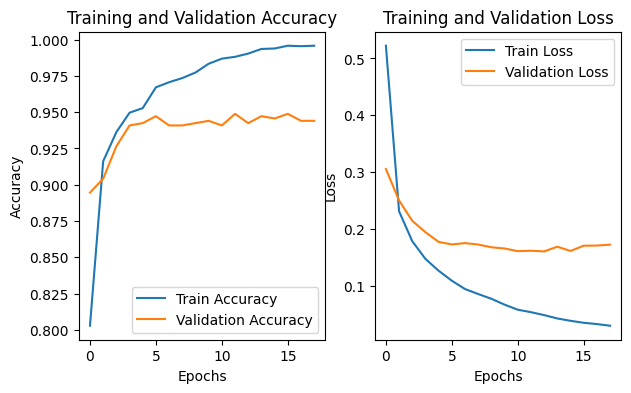

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()

14/14 ━━━━━━━━━━━━━━━━━━━━ 11s 487ms/step
                precision    recall  f1-score   support

        Blight       0.91      0.83      0.87       116
   Common_Rust       0.95      0.97      0.96       132
Gray_Leaf_Spot       0.76      0.83      0.79        58
       Healthy       0.97      1.00      0.99       117

      accuracy                           0.92       423
     macro avg       0.90      0.91      0.90       423
  weighted avg       0.92      0.92      0.92       423



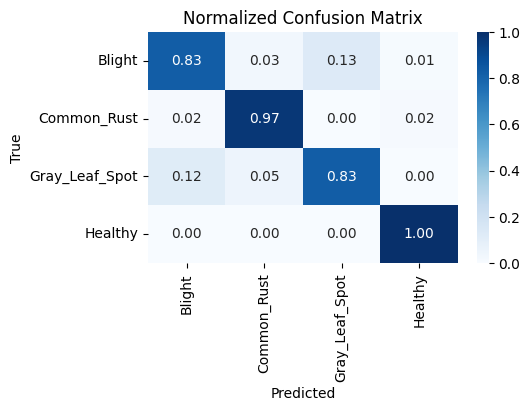

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Get true labels and predictions
test_generator.reset()
y_true = test_generator.classes
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
class_labels = list(test_generator.class_indices.keys())

# Classification report
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

# Compute Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Normalize confusion matrix between 0 and 1
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

# Plot normalized Confusion Matrix
plt.figure(figsize=(5, 3))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Normalized Confusion Matrix')
plt.show()


# AlexNet without Data Augmentation

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define dataset directories
train_dir = "/content/drive/MyDrive/CornSplit/train"
val_dir = "/content/drive/MyDrive/CornSplit/val"
test_dir = "/content/drive/MyDrive/CornSplit/test"

# Define ImageDataGenerators for data loading and augmentation
train_datagen = ImageDataGenerator(
    #rescale=1./255, rotation_range=20, width_shift_range=0.2, height_shift_range=0.2, horizontal_flip=True
)
val_test_datagen = ImageDataGenerator()

# Set batch size and image size
batch_size = 32
img_size = (227, 227)  # AlexNet uses 227x227 input size

# Load images from directories
train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=True
)
val_generator = val_test_datagen.flow_from_directory(
    val_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=False
)
test_generator = val_test_datagen.flow_from_directory(
    test_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=False
)

# Build AlexNet model
model = Sequential([
    Conv2D(96, (11, 11), strides=4, activation='relu', input_shape=(227, 227, 3)),
    MaxPooling2D((3, 3), strides=2),
    Conv2D(256, (5, 5), padding='same', activation='relu'),
    MaxPooling2D((3, 3), strides=2),
    Conv2D(384, (3, 3), padding='same', activation='relu'),
    Conv2D(384, (3, 3), padding='same', activation='relu'),
    Conv2D(256, (3, 3), padding='same', activation='relu'),
    MaxPooling2D((3, 3), strides=2),
    Flatten(),
    Dense(4096, activation='relu'),
    Dropout(0.5),
    Dense(4096, activation='relu'),
    Dropout(0.5),
    Dense(len(train_generator.class_indices), activation='softmax')
])

# Compile model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

# Callbacks for early stopping and saving best model
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint("/content/drive/MyDrive/AfriModels/AlexNetwithoutDA.h5", save_best_only=True, monitor='val_accuracy')

# Train model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=[early_stop, checkpoint]
)

# Save the final model
model.save("/content/drive/MyDrive/AfriModels/alexnet_final_model.h5")


Found 3139 images belonging to 4 classes.
Found 626 images belonging to 4 classes.
Found 423 images belonging to 4 classes.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 55, 55, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 27, 27, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 27, 27, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 13, 13, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 13, 13, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4096)           │    37,752,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 4)              │        16,388 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,297,732 (222.39 MB)

 Trainable params: 58,297,732 (222.39 MB)

...

99/99 ━━━━━━━━━━━━━━━━━━━━ 40s 360ms/step - accuracy: 0.5105 - loss: 4.3360 - val_accuracy: 0.8067 - val_loss: 0.5054
Epoch 2/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.7991 - loss: 0.4922

99/99 ━━━━━━━━━━━━━━━━━━━━ 35s 351ms/step - accuracy: 0.7993 - loss: 0.4918 - val_accuracy: 0.8498 - val_loss: 0.3519
Epoch 3/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 0.8353 - loss: 0.3750

99/99 ━━━━━━━━━━━━━━━━━━━━ 56s 504ms/step - accuracy: 0.8354 - loss: 0.3750 - val_accuracy: 0.8626 - val_loss: 0.3827
Epoch 4/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 40s 405ms/step - accuracy: 0.8690 - loss: 0.3223 - val_accuracy: 0.8211 - val_loss: 0.5037
Epoch 5/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 18s 183ms/step - accuracy: 0.8710 - loss: 0.3026 - val_accuracy: 0.8562 - val_loss: 0.3538
Epoch 6/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.9111 - loss: 0.2363

99/99 ━━━━━━━━━━━━━━━━━━━━ 37s 375ms/step - accuracy: 0.9109 - loss: 0.2365 - val_accuracy: 0.8818 - val_loss: 0.4260
Epoch 7/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 39s 398ms/step - accuracy: 0.9046 - loss: 0.2758 - val_accuracy: 0.8770 - val_loss: 0.2856
Epoch 8/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 21s 210ms/step - accuracy: 0.9171 - loss: 0.2025 - val_accuracy: 0.8514 - val_loss: 0.4166
Epoch 9/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9075 - loss: 0.2313

99/99 ━━━━━━━━━━━━━━━━━━━━ 33s 332ms/step - accuracy: 0.9076 - loss: 0.2311 - val_accuracy: 0.8962 - val_loss: 0.2736
Epoch 10/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 40s 404ms/step - accuracy: 0.9368 - loss: 0.1595 - val_accuracy: 0.8291 - val_loss: 0.4318
Epoch 11/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 19s 195ms/step - accuracy: 0.9050 - loss: 0.2721 - val_accuracy: 0.8674 - val_loss: 0.3425
Epoch 12/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 18s 186ms/step - accuracy: 0.9332 - loss: 0.1693 - val_accuracy: 0.8882 - val_loss: 0.3043
Epoch 13/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 22s 218ms/step - accuracy: 0.9492 - loss: 0.1367 - val_accuracy: 0.8962 - val_loss: 0.2711
Epoch 14/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 18s 186ms/step - accuracy: 0.9584 - loss: 0.1118 - val_accuracy: 0.8754 - val_loss: 0.3200
Epoch 15/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 18s 183ms/step - accuracy: 0.9503 - loss: 0.1217 - val_accuracy: 0.8802 - val_loss: 0.2955
Epoch 16/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 19s 189ms/step - accuracy: 0.9616 - loss: 0.0985 - val_accuracy

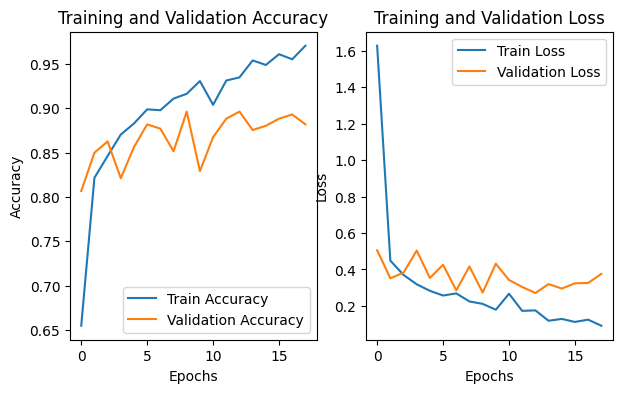

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()

14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 202ms/step
                precision    recall  f1-score   support

        Blight       0.84      0.84      0.84       116
   Common_Rust       0.98      0.94      0.96       132
Gray_Leaf_Spot       0.66      0.69      0.67        58
       Healthy       0.99      1.00      1.00       117

      accuracy                           0.90       423
     macro avg       0.87      0.87      0.87       423
  weighted avg       0.90      0.90      0.90       423



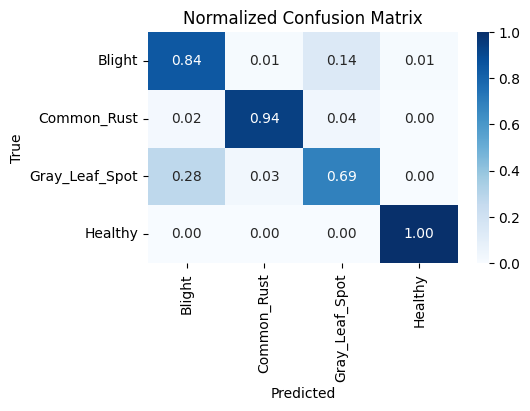

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Get true labels and predictions
test_generator.reset()
y_true = test_generator.classes
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
class_labels = list(test_generator.class_indices.keys())

# Classification report
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

# Compute Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Normalize confusion matrix between 0 and 1
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

# Plot normalized Confusion Matrix
plt.figure(figsize=(5, 3))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Normalized Confusion Matrix')
plt.show()

# confidence interval

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define dataset directories
train_dir = "/content/drive/MyDrive/CornSplit/train"
val_dir = "/content/drive/MyDrive/CornSplit/val"
test_dir = "/content/drive/MyDrive/CornSplit/test"

# Define ImageDataGenerators for data loading and augmentation
train_datagen = ImageDataGenerator(
)
val_test_datagen = ImageDataGenerator()

# Set batch size and image size
batch_size = 32
img_size = (224, 224)

# Load images from directories
train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=True
)
val_generator = val_test_datagen.flow_from_directory(
    val_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=False
)
test_generator = val_test_datagen.flow_from_directory(
    test_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=False
)


Found 3139 images belonging to 4 classes.
Found 626 images belonging to 4 classes.
Found 423 images belonging to 4 classes.


# for VGG16

In [ ]:

from tensorflow.keras.models import load_model

# Path to your saved .h5 model
model_path = "/content/drive/MyDrive/AfriModels/vgg16_final_model.h5"

# Load the model
model = load_model(model_path)

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import load_model
from tqdm import tqdm

# Load your trained model (if not already in memory)
#model = load_model("/content/drive/MyDrive/AfriModels/vgg16_final_model.h5")

# Evaluate model on test data
test_generator.reset()
preds = model.predict(test_generator, verbose=1)
y_pred = np.argmax(preds, axis=1)
y_true = test_generator.classes

# Bootstrapping function for confidence interval
def bootstrap_ci(y_true, y_pred, metric_fn=accuracy_score, n_iterations=1000, alpha=0.95):
    scores = []
    n = len(y_true)
    for _ in tqdm(range(n_iterations)):
        indices = np.random.randint(0, n, n)
        score = metric_fn(np.array(y_true)[indices], np.array(y_pred)[indices])
        scores.append(score)
    lower = np.percentile(scores, ((1 - alpha) / 2) * 100)
    upper = np.percentile(scores, (1 - (1 - alpha) / 2) * 100)
    return lower, upper

# Get accuracy and confidence interval
acc = accuracy_score(y_true, y_pred)
ci_lower, ci_upper = bootstrap_ci(y_true, y_pred)

print(f"Test Accuracy: {acc:.4f}")
print(f"95% Confidence Interval for Accuracy: ({ci_lower:.4f}, {ci_upper:.4f})")


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


14/14 ━━━━━━━━━━━━━━━━━━━━ 147s 10s/step


100%|██████████| 1000/1000 [00:00<00:00, 2612.49it/s]

Test Accuracy: 0.9078
95% Confidence Interval for Accuracy: (0.8794, 0.9362)


# for ResNet50

In [ ]:

from tensorflow.keras.models import load_model

# Path to your saved .h5 model
model_path = "/content/drive/MyDrive/AfriModels/resnet50_final_model.h5"

# Load the model
model_res = load_model(model_path)

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import load_model
from tqdm import tqdm

# Load your trained model (if not already in memory)
#model = load_model("/content/drive/MyDrive/AfriModels/vgg16_final_model.h5")

# Evaluate model on test data
test_generator.reset()
preds = model_res.predict(test_generator, verbose=1)
y_pred = np.argmax(preds, axis=1)
y_true = test_generator.classes

# Bootstrapping function for confidence interval
def bootstrap_ci(y_true, y_pred, metric_fn=accuracy_score, n_iterations=1000, alpha=0.95):
    scores = []
    n = len(y_true)
    for _ in tqdm(range(n_iterations)):
        indices = np.random.randint(0, n, n)
        score = metric_fn(np.array(y_true)[indices], np.array(y_pred)[indices])
        scores.append(score)
    lower = np.percentile(scores, ((1 - alpha) / 2) * 100)
    upper = np.percentile(scores, (1 - (1 - alpha) / 2) * 100)
    return lower, upper

# Get accuracy and confidence interval
acc = accuracy_score(y_true, y_pred)
ci_lower, ci_upper = bootstrap_ci(y_true, y_pred)

print(f"Test Accuracy: {acc:.4f}")
print(f"95% Confidence Interval for Accuracy: ({ci_lower:.4f}, {ci_upper:.4f})")


14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 375ms/step


100%|██████████| 1000/1000 [00:00<00:00, 1877.85it/s]

Test Accuracy: 0.2931
95% Confidence Interval for Accuracy: (0.2482, 0.3334)


# K-fold cross validation

# VGG16

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import KFold
import numpy as np
import os

# Define dataset directories
train_dir = "/content/drive/MyDrive/CornSplit/train"
val_dir = "/content/drive/MyDrive/CornSplit/val"
test_dir = "/content/drive/MyDrive/CornSplit/test"

# Define ImageDataGenerators for data loading and augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=20, width_shift_range=0.2, height_shift_range=0.2, horizontal_flip=True
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Set batch size and image size
batch_size = 32
img_size = (224, 224)

# Load images from directories
train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=False
)

# Create a custom generator for splitting the data
class CustomDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, filenames, labels, batch_size, img_size, mode='train', num_classes=4):
        self.filenames = filenames
        self.labels = labels
        self.batch_size = batch_size
        self.img_size = img_size
        self.mode = mode
        self.num_classes = num_classes

    def __len__(self):
        return int(np.floor(len(self.filenames) / self.batch_size))

    def __getitem__(self, idx):
        batch_filenames = self.filenames[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_labels = self.labels[idx * self.batch_size:(idx + 1) * self.batch_size]
        return self.__data_generation(batch_filenames, batch_labels)

    def __data_generation(self, batch_filenames, batch_labels):
        images = []
        for filename in batch_filenames:
            img_path = os.path.join(train_dir, filename)
            img = tf.keras.preprocessing.image.load_img(img_path, target_size=self.img_size)
            img = tf.keras.preprocessing.image.img_to_array(img)
            images.append(img)

        # One-hot encode the labels
        batch_labels_one_hot = np.eye(self.num_classes)[batch_labels]

        return np.array(images), batch_labels_one_hot

# Extract the filenames and labels
filenames = train_generator.filenames
labels = train_generator.classes

# Set up K-Fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)  # 5-fold cross-validation

for fold, (train_idx, val_idx) in enumerate(kf.split(filenames)):
    print(f"Training fold {fold + 1}/{kf.get_n_splits()}")

    # Split the data into training and validation sets based on the indices
    train_filenames = np.array(filenames)[train_idx]
    val_filenames = np.array(filenames)[val_idx]

    train_labels = np.array(labels)[train_idx]
    val_labels = np.array(labels)[val_idx]

    # Create custom data generators for the current fold
    train_data_gen = CustomDataGenerator(train_filenames, train_labels, batch_size, img_size, mode='train', num_classes=len(train_generator.class_indices))
    val_data_gen = CustomDataGenerator(val_filenames, val_labels, batch_size, img_size, mode='val', num_classes=len(train_generator.class_indices))

    # Load VGG16 model without the classification head
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

    # Set base model trainability
    base_model.trainable = True

    # Add custom layers on top of VGG16
    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(128, activation='relu')(x)
    x = Dense(len(train_generator.class_indices), activation='softmax')(x)

    # Create final model
    model = Model(inputs=base_model.input, outputs=x)

    # Compile model
    model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

    # Callbacks for early stopping and saving best model
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    checkpoint = ModelCheckpoint(f"/content/drive/MyDrive/AfriModels/vgg16_best_model_fold_{fold}.h5", save_best_only=True, monitor='val_accuracy')

    # Train model
    history = model.fit(
        train_data_gen,
        validation_data=val_data_gen,
        epochs=50,
        callbacks=[early_stop, checkpoint]
    )

    # Save the final model for this fold
    model.save(f"/content/drive/MyDrive/AfriModels/vgg16_final_model_fold_{fold}.h5")

    # Optionally: Evaluate model performance on the test set after each fold
    # test_score = model.evaluate(test_generator)
    # print(f"Test accuracy for fold {fold + 1}: {test_score[1]}")


Found 3139 images belonging to 4 classes.
Training fold 1/5
Epoch 1/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.2619 - loss: 2.8790

78/78 ━━━━━━━━━━━━━━━━━━━━ 880s 11s/step - accuracy: 0.2633 - loss: 2.8638 - val_accuracy: 0.4984 - val_loss: 1.0183
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.5613 - loss: 1.1522

78/78 ━━━━━━━━━━━━━━━━━━━━ 39s 500ms/step - accuracy: 0.5617 - loss: 1.1496 - val_accuracy: 0.6184 - val_loss: 0.9541
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 44s 550ms/step - accuracy: 0.6547 - loss: 0.8667 - val_accuracy: 0.5280 - val_loss: 0.8168
Epoch 4/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.7334 - loss: 0.6256

78/78 ━━━━━━━━━━━━━━━━━━━━ 40s 516ms/step - accuracy: 0.7339 - loss: 0.6245 - val_accuracy: 0.8224 - val_loss: 0.4478
Epoch 5/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 500ms/step - accuracy: 0.8158 - loss: 0.4340

78/78 ━━━━━━━━━━━━━━━━━━━━ 45s 576ms/step - accuracy: 0.8157 - loss: 0.4339 - val_accuracy: 0.8257 - val_loss: 0.4467
Epoch 6/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.8078 - loss: 0.4040

...

78/78 ━━━━━━━━━━━━━━━━━━━━ 40s 517ms/step - accuracy: 0.8106 - loss: 0.5427 - val_accuracy: 0.8059 - val_loss: 0.4750
Epoch 6/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 43s 550ms/step - accuracy: 0.7527 - loss: 0.5519 - val_accuracy: 0.7763 - val_loss: 0.5224
Epoch 7/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - accuracy: 0.7897 - loss: 0.5019

78/78 ━━━━━━━━━━━━━━━━━━━━ 41s 531ms/step - accuracy: 0.7897 - loss: 0.5018 - val_accuracy: 0.8372 - val_loss: 0.5155
Epoch 8/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 43s 553ms/step - accuracy: 0.8278 - loss: 0.4323 - val_accuracy: 0.8339 - val_loss: 0.4453
Epoch 9/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 39s 496ms/step - accuracy: 0.7503 - loss: 0.4585 - val_accuracy: 0.8289 - val_loss: 0.4046
Epoch 10/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 41s 521ms/step - accuracy: 0.8400 - loss: 0.3837 - val_accuracy: 0.8273 - val_loss: 0.5407
Epoch 11/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 39s 499ms/step - accuracy: 0.7715 - loss: 0.4820 - val_accuracy: 0.8273 - val_loss: 0.5075
Epoch 12/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.8435 - loss: 0.3870

78/78 ━━━━━━━━━━━━━━━━━━━━ 42s 534ms/step - accuracy: 0.8433 - loss: 0.3869 - val_accuracy: 0.8421 - val_loss: 0.3638
Epoch 13/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 48s 558ms/step - accuracy: 0.7564 - loss: 0.4225 - val_accuracy: 0.8405 - val_loss: 0.7216
Epoch 14/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 39s 493ms/step - accuracy: 0.8315 - loss: 0.5707 - val_accuracy: 0.8125 - val_loss: 0.5782
Epoch 15/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.7768 - loss: 0.5539

78/78 ━━━━━━━━━━━━━━━━━━━━ 40s 516ms/step - accuracy: 0.7770 - loss: 0.5529 - val_accuracy: 0.8438 - val_loss: 0.7265
Epoch 16/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 45s 568ms/step - accuracy: 0.8693 - loss: 0.4005 - val_accuracy: 0.8421 - val_loss: 0.3992
Epoch 17/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.7382 - loss: 0.4361

78/78 ━━━━━━━━━━━━━━━━━━━━ 41s 519ms/step - accuracy: 0.7393 - loss: 0.4359 - val_accuracy: 0.8454 - val_loss: 0.3975


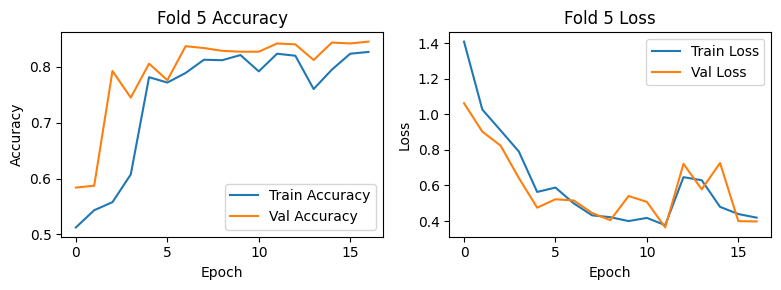

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy and loss
plt.figure(figsize=(8, 3))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title(f'Fold {fold + 1} Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title(f'Fold {fold + 1} Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define dataset directories
train_dir = "/content/drive/MyDrive/CornSplit/train"
val_dir = "/content/drive/MyDrive/CornSplit/val"
test_dir = "/content/drive/MyDrive/CornSplit/test"

# Define ImageDataGenerators for data loading and augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=20, width_shift_range=0.2, height_shift_range=0.2, horizontal_flip=True
)
val_test_datagen = ImageDataGenerator()

# Set batch size and image size
batch_size = 32
img_size = (227, 227)  # AlexNet uses 227x227 input size

# Load images from directories
train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=True
)
val_generator = val_test_datagen.flow_from_directory(
    val_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=False
)
test_generator = val_test_datagen.flow_from_directory(
    test_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=False
)

Found 3139 images belonging to 4 classes.
Found 626 images belonging to 4 classes.
Found 423 images belonging to 4 classes.


Found 423 images belonging to 4 classes.


423/423 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step

Classification Report:
                precision    recall  f1-score   support

        Blight       0.00      0.00      0.00       116
   Common_Rust       0.31      1.00      0.48       132
Gray_Leaf_Spot       0.00      0.00      0.00        58
       Healthy       0.00      0.00      0.00       117

      accuracy                           0.31       423
     macro avg       0.08      0.25      0.12       423
  weighted avg       0.10      0.31      0.15       423



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


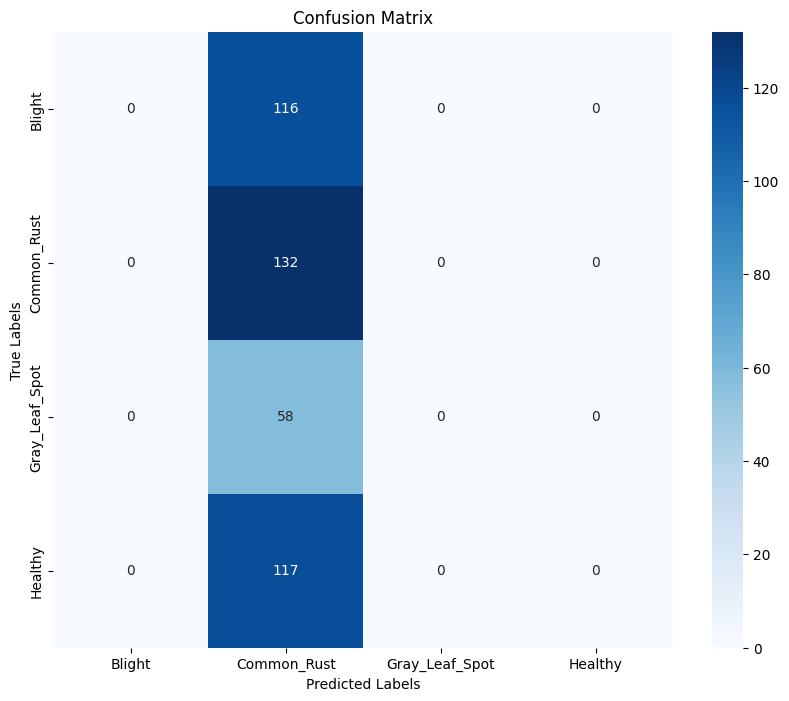

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Define test dataset directory
test_dir = "/content/drive/MyDrive/CornSplit/test"

# Image parameters
img_size = (224, 224)  # AlexNet/VGG input size
batch_size = 1  # For accurate per-image prediction

# ImageDataGenerator for testing (rescale only)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load test data
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# Load the best saved model
model = load_model("/content/drive/MyDrive/AfriModels/vgg16_best_model_fold_0.h5")

# Predict on the test data
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

# Get class labels
class_labels = list(test_generator.class_indices.keys())

# Print classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

# Plot confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

Found 423 images belonging to 4 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


423/423 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step

Classification Report:
                precision    recall  f1-score   support

        Blight       0.00      0.00      0.00       116
   Common_Rust       0.32      1.00      0.49       132
Gray_Leaf_Spot       0.54      0.12      0.20        58
       Healthy       0.00      0.00      0.00       117

      accuracy                           0.33       423
     macro avg       0.22      0.28      0.17       423
  weighted avg       0.17      0.33      0.18       423



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


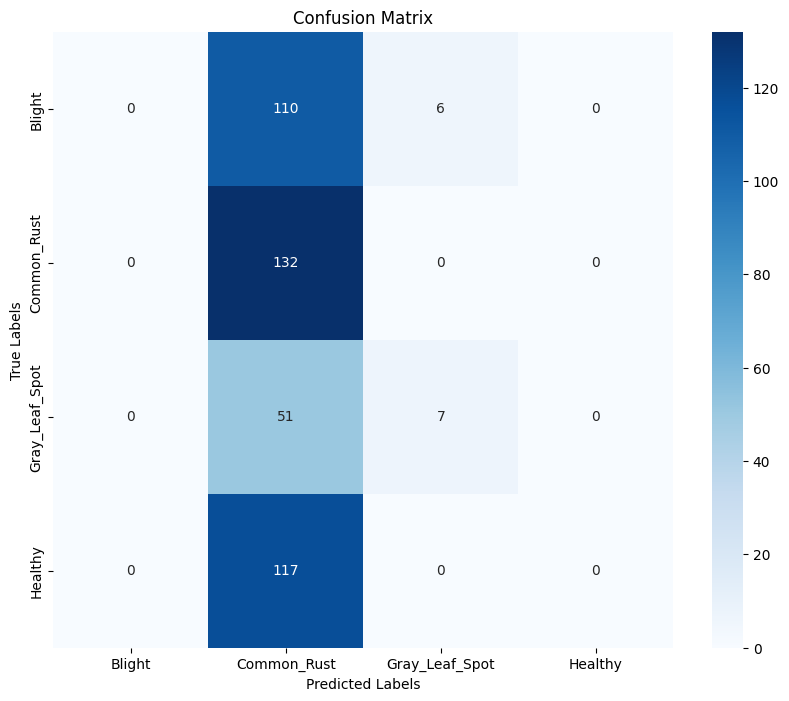

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Define test dataset directory
test_dir = "/content/drive/MyDrive/CornSplit/test"

# Image parameters
img_size = (224, 224)  # AlexNet/VGG input size
batch_size = 1  # For accurate per-image prediction

# ImageDataGenerator for testing (rescale only)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load test data
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# Load the best saved model
model = load_model("/content/drive/MyDrive/AfriModels/vgg16_best_model_fold_1.h5")

# Predict on the test data
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

# Get class labels
class_labels = list(test_generator.class_indices.keys())

# Print classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

# Plot confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

Found 423 images belonging to 4 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


423/423 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step

Classification Report:
                precision    recall  f1-score   support

        Blight       0.00      0.00      0.00       116
   Common_Rust       0.31      0.99      0.47       132
Gray_Leaf_Spot       0.00      0.00      0.00        58
       Healthy       0.00      0.00      0.00       117

      accuracy                           0.31       423
     macro avg       0.08      0.25      0.12       423
  weighted avg       0.10      0.31      0.15       423



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


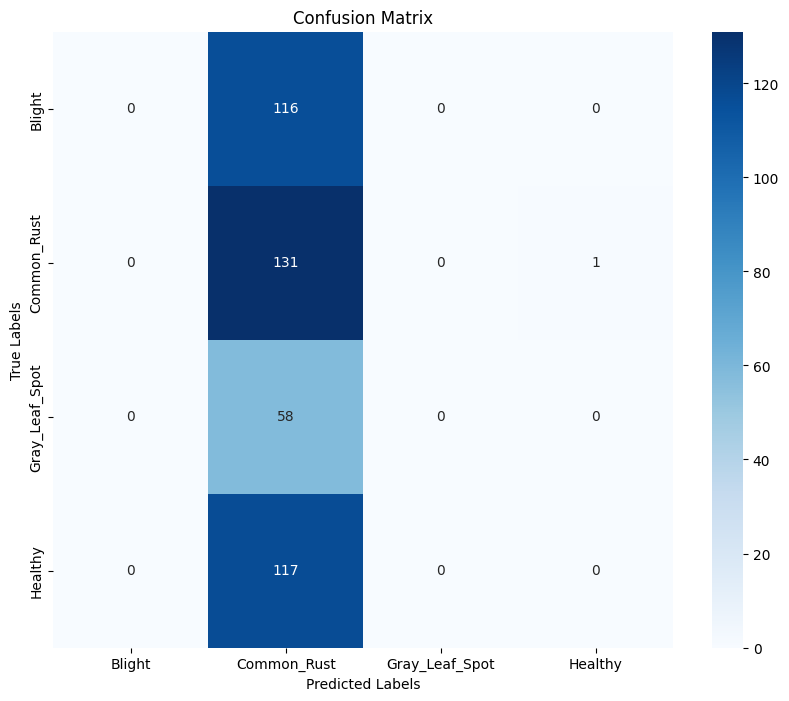

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Define test dataset directory
test_dir = "/content/drive/MyDrive/CornSplit/test"

# Image parameters
img_size = (224, 224)  # AlexNet/VGG input size
batch_size = 1  # For accurate per-image prediction

# ImageDataGenerator for testing (rescale only)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load test data
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# Load the best saved model
model = load_model("/content/drive/MyDrive/AfriModels/vgg16_best_model_fold_2.h5")

# Predict on the test data
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

# Get class labels
class_labels = list(test_generator.class_indices.keys())

# Print classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

# Plot confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

Found 423 images belonging to 4 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


423/423 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step

Classification Report:
                precision    recall  f1-score   support

        Blight       0.00      0.00      0.00       116
   Common_Rust       0.00      0.00      0.00       132
Gray_Leaf_Spot       0.00      0.00      0.00        58
       Healthy       0.28      1.00      0.43       117

      accuracy                           0.28       423
     macro avg       0.07      0.25      0.11       423
  weighted avg       0.08      0.28      0.12       423



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


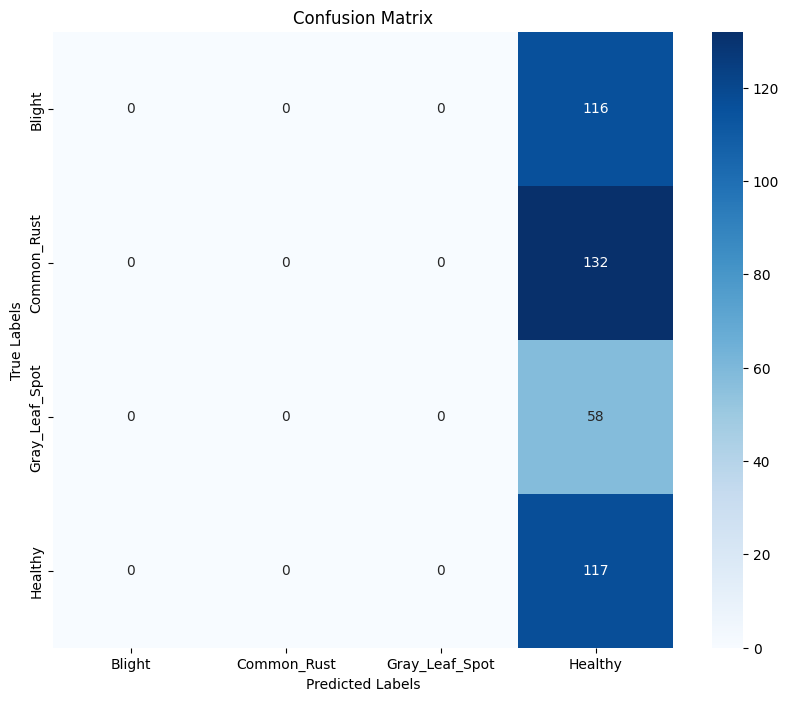

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Define test dataset directory
test_dir = "/content/drive/MyDrive/CornSplit/test"

# Image parameters
img_size = (224, 224)  # AlexNet/VGG input size
batch_size = 1  # For accurate per-image prediction

# ImageDataGenerator for testing (rescale only)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load test data
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# Load the best saved model
model = load_model("/content/drive/MyDrive/AfriModels/vgg16_best_model_fold_4.h5")

# Predict on the test data
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

# Get class labels
class_labels = list(test_generator.class_indices.keys())

# Print classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

# Plot confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

Found 423 images belonging to 4 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


423/423 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step

Classification Report:
                precision    recall  f1-score   support

        Blight       0.00      0.00      0.00       116
   Common_Rust       0.00      0.00      0.00       132
Gray_Leaf_Spot       0.00      0.00      0.00        58
       Healthy       0.28      1.00      0.43       117

      accuracy                           0.28       423
     macro avg       0.07      0.25      0.11       423
  weighted avg       0.08      0.28      0.12       423



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


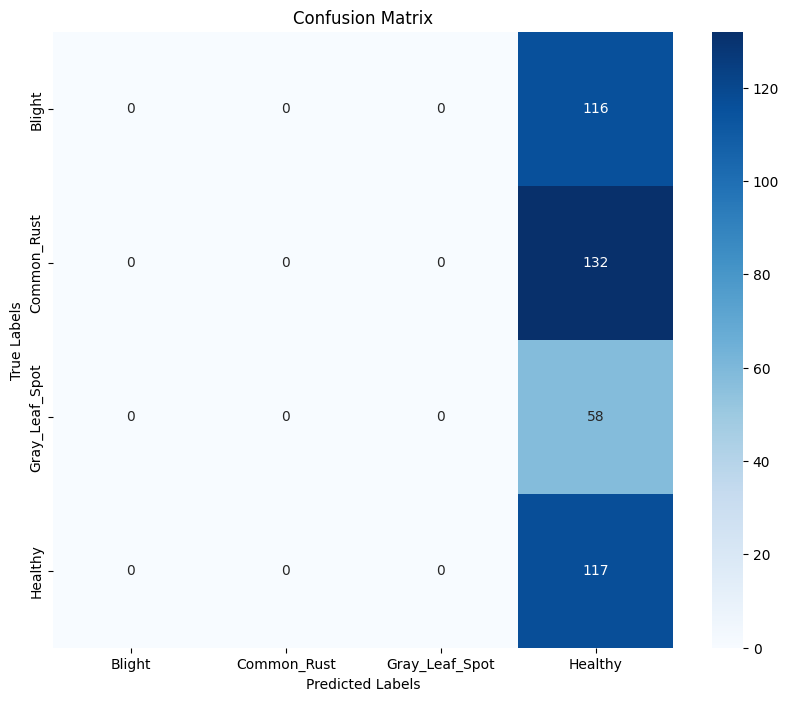

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Define test dataset directory
test_dir = "/content/drive/MyDrive/CornSplit/test"

# Image parameters
img_size = (224, 224)  # AlexNet/VGG input size
batch_size = 1  # For accurate per-image prediction

# ImageDataGenerator for testing (rescale only)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load test data
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# Load the best saved model
model = load_model("/content/drive/MyDrive/AfriModels/vgg16_best_model_fold_4.h5")

# Predict on the test data
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

# Get class labels
class_labels = list(test_generator.class_indices.keys())

# Print classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

# Plot confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# ResNet50

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import KFold
import numpy as np
import os

# Dataset directories
train_dir = "/content/drive/MyDrive/CornSplit/train"
val_dir = "/content/drive/MyDrive/CornSplit/val"
test_dir = "/content/drive/MyDrive/CornSplit/test"

# Image settings
batch_size = 32
img_size = (224, 224)

# ImageDataGenerators
train_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=20, width_shift_range=0.2,
    height_shift_range=0.2, horizontal_flip=True
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Initial load to get filenames and labels
train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=False
)

# Custom generator
class CustomDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, filenames, labels, batch_size, img_size, mode='train', num_classes=4):
        self.filenames = filenames
        self.labels = labels
        self.batch_size = batch_size
        self.img_size = img_size
        self.mode = mode
        self.num_classes = num_classes
        self.augment = ImageDataGenerator(
            rescale=1./255,
            rotation_range=20, width_shift_range=0.2, height_shift_range=0.2, horizontal_flip=True
        ) if mode == 'train' else ImageDataGenerator(rescale=1./255)

    def __len__(self):
        return int(np.floor(len(self.filenames) / self.batch_size))

    def __getitem__(self, idx):
        batch_filenames = self.filenames[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_labels = self.labels[idx * self.batch_size:(idx + 1) * self.batch_size]
        return self.__data_generation(batch_filenames, batch_labels)

    def __data_generation(self, batch_filenames, batch_labels):
        images = []
        for filename in batch_filenames:
            img_path = os.path.join(train_dir, filename)
            img = tf.keras.preprocessing.image.load_img(img_path, target_size=self.img_size)
            img = tf.keras.preprocessing.image.img_to_array(img)
            images.append(img)

        images = np.array(images)
        images = self.augment.standardize(images)
        batch_labels_one_hot = tf.keras.utils.to_categorical(batch_labels, num_classes=self.num_classes)

        return images, batch_labels_one_hot

# Prepare file names and labels
filenames = train_generator.filenames
labels = train_generator.classes
num_classes = len(train_generator.class_indices)

# KFold setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(kf.split(filenames)):
    print(f"\n--- Training Fold {fold + 1}/5 ---")

    # Split
    train_filenames = np.array(filenames)[train_idx]
    val_filenames = np.array(filenames)[val_idx]
    train_labels = np.array(labels)[train_idx]
    val_labels = np.array(labels)[val_idx]

    # Generators
    train_data_gen = CustomDataGenerator(train_filenames, train_labels, batch_size, img_size, mode='train', num_classes=num_classes)
    val_data_gen = CustomDataGenerator(val_filenames, val_labels, batch_size, img_size, mode='val', num_classes=num_classes)

    # Model
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(128, activation='relu')(x)
    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)

    model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

    # Callbacks
    checkpoint_path = f"/content/drive/MyDrive/AfriModels/resnet50_best_model_fold_{fold}.h5"
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    checkpoint = ModelCheckpoint(checkpoint_path, save_best_only=True, monitor='val_accuracy')

    # Training
    history = model.fit(
        train_data_gen,
        validation_data=val_data_gen,
        epochs=50,
        callbacks=[early_stop, checkpoint]
    )

    # Save final model
    model.save(f"/content/drive/MyDrive/AfriModels/resnet50_final_model_fold_{fold}.h5")


Found 3139 images belonging to 4 classes.

--- Training Fold 1/5 ---
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.2422 - loss: 1.4718

78/78 ━━━━━━━━━━━━━━━━━━━━ 72s 264ms/step - accuracy: 0.2423 - loss: 1.4713 - val_accuracy: 0.2566 - val_loss: 1.3475
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.3618 - loss: 1.3322

78/78 ━━━━━━━━━━━━━━━━━━━━ 18s 230ms/step - accuracy: 0.3616 - loss: 1.3325 - val_accuracy: 0.3158 - val_loss: 1.3185
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 17s 215ms/step - accuracy: 0.2852 - loss: 1.3736 - val_accuracy: 0.3158 - val_loss: 1.3184
Epoch 4/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 16s 199ms/step - accuracy: 0.2195 - loss: 1.3761 - val_accuracy: 0.3158 - val_loss: 1.2927
Epoch 5/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.3459 - loss: 1.3380

...

78/78 ━━━━━━━━━━━━━━━━━━━━ 19s 227ms/step - accuracy: 0.5533 - loss: 1.2243 - val_accuracy: 0.5757 - val_loss: 1.2015
Epoch 18/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 19s 210ms/step - accuracy: 0.5692 - loss: 1.2121 - val_accuracy: 0.5296 - val_loss: 1.2060
Epoch 19/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.4717 - loss: 1.2391

78/78 ━━━━━━━━━━━━━━━━━━━━ 19s 239ms/step - accuracy: 0.4718 - loss: 1.2391 - val_accuracy: 0.6036 - val_loss: 1.1869
Epoch 20/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 16s 205ms/step - accuracy: 0.5019 - loss: 1.1698 - val_accuracy: 0.5033 - val_loss: 1.2114
Epoch 21/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 16s 203ms/step - accuracy: 0.3557 - loss: 1.2412 - val_accuracy: 0.3520 - val_loss: 1.2088
Epoch 22/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 16s 199ms/step - accuracy: 0.4116 - loss: 1.2849 - val_accuracy: 0.5789 - val_loss: 1.1664
Epoch 23/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 15s 197ms/step - accuracy: 0.5027 - loss: 1.2066 - val_accuracy: 0.5724 - val_loss: 1.1754
Epoch 24/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 22s 210ms/step - accuracy: 0.4850 - loss: 1.2368 - val_accuracy: 0.5559 - val_loss: 1.1560
Epoch 25/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 22s 226ms/step - accuracy: 0.5028 - loss: 1.2289 - val_accuracy: 0.4194 - val_loss: 1.1841
Epoch 26/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.4810 - loss: 1.1776

78/78 ━━━━━━━━━━━━━━━━━━━━ 21s 266ms/step - accuracy: 0.4808 - loss: 1.1780 - val_accuracy: 0.6924 - val_loss: 1.1492
Epoch 27/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 18s 224ms/step - accuracy: 0.4720 - loss: 1.2057 - val_accuracy: 0.5691 - val_loss: 1.1417
Epoch 28/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.4308 - loss: 1.3301

78/78 ━━━━━━━━━━━━━━━━━━━━ 19s 249ms/step - accuracy: 0.4319 - loss: 1.3285 - val_accuracy: 0.6941 - val_loss: 1.1307
Epoch 29/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 16s 211ms/step - accuracy: 0.5400 - loss: 1.1826 - val_accuracy: 0.5888 - val_loss: 1.1257
Epoch 30/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 15s 197ms/step - accuracy: 0.4948 - loss: 1.2021 - val_accuracy: 0.6513 - val_loss: 1.1224
Epoch 31/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 15s 197ms/step - accuracy: 0.5529 - loss: 1.1345 - val_accuracy: 0.5674 - val_loss: 1.1325
Epoch 32/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 16s 202ms/step - accuracy: 0.4580 - loss: 1.1235 - val_accuracy: 0.6118 - val_loss: 1.1176
Epoch 33/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 16s 201ms/step - accuracy: 0.5057 - loss: 1.1332 - val_accuracy: 0.5707 - val_loss: 1.1388
Epoch 34/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 15s 196ms/step - accuracy: 0.4153 - loss: 1.2497 - val_accuracy: 0.5674 - val_loss: 1.1061
Epoch 35/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 15s 196ms/step - accuracy: 0.5571 - loss: 1.1275 - val_accuracy

78/78 ━━━━━━━━━━━━━━━━━━━━ 21s 274ms/step - accuracy: 0.5732 - loss: 1.0727 - val_accuracy: 0.6990 - val_loss: 1.0566
Epoch 44/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 35s 201ms/step - accuracy: 0.5934 - loss: 1.1078 - val_accuracy: 0.5921 - val_loss: 1.0527
Epoch 45/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 20s 197ms/step - accuracy: 0.5447 - loss: 1.1201 - val_accuracy: 0.6842 - val_loss: 1.0469
Epoch 46/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 15s 198ms/step - accuracy: 0.5790 - loss: 1.0904 - val_accuracy: 0.5806 - val_loss: 1.0607
Epoch 47/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 15s 195ms/step - accuracy: 0.5664 - loss: 1.0559 - val_accuracy: 0.5493 - val_loss: 1.0882
Epoch 48/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 16s 202ms/step - accuracy: 0.5845 - loss: 1.0464 - val_accuracy: 0.6760 - val_loss: 1.0345
Epoch 49/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 16s 199ms/step - accuracy: 0.4973 - loss: 1.1449 - val_accuracy: 0.6184 - val_loss: 1.0231
Epoch 50/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 16s 201ms/step - accuracy: 0.5564 - loss: 1.0960 - val_accuracy

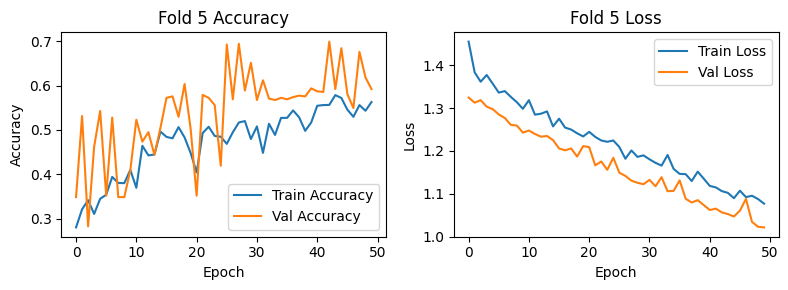

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy and loss
plt.figure(figsize=(8, 3))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title(f'Fold {fold + 1} Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title(f'Fold {fold + 1} Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# MobileNet

In [ ]:
pip install tensorflow scikit-learn matplotlib seaborn

# mobileNet without data augmentation

Found 3139 images belonging to 4 classes.
Found 626 images belonging to 4 classes.
Found 423 images belonging to 4 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1328s 13s/step - accuracy: 0.7667 - loss: 0.5925 - val_accuracy: 0.9089 - val_loss: 0.2369
Epoch 2/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 21s 210ms/step - accuracy: 0.9298 - loss: 0.1879 - val_accuracy: 0.9217 - val_loss: 0.1992
Epoch 3/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 20s 199ms/step - accuracy: 0.9308 - loss: 0.1702 - val_accuracy: 0.9010 - val_loss: 0.2351
Epoch 4/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 20s 206ms/step - accuracy: 0.9456 - loss: 0.1457 - val_accuracy: 0.9313 - val_loss: 0.1724
Epoch 5/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 19s 193ms/step - accuracy: 0.9577 - loss: 0.0996 - val_accuracy: 0.9265 - val_loss: 0.1845
Epoch 6/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 21s 197ms/step - accuracy: 0.9661 - loss: 0.0909 - val_accuracy: 0.9377 - val_loss: 0.1823
Epoch 7/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 19s 191ms/step - accuracy: 0.9702 - loss: 0.0732 - val_accuracy: 0.9345 - val_loss: 0.2005
Epoch 8/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 20s 205ms/step - accuracy: 0.9753 - loss: 0.0655 - val_accu

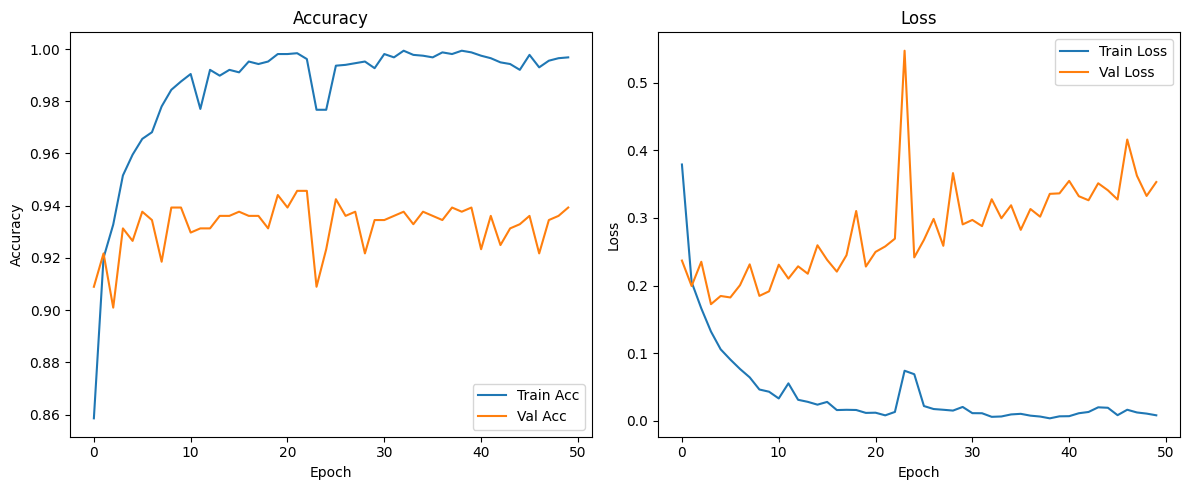

14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 405ms/step

Classification Report:
                precision    recall  f1-score   support

        Blight       0.90      0.85      0.88       116
   Common_Rust       0.97      0.98      0.98       132
Gray_Leaf_Spot       0.76      0.81      0.78        58
       Healthy       1.00      1.00      1.00       117

      accuracy                           0.93       423
     macro avg       0.91      0.91      0.91       423
  weighted avg       0.93      0.93      0.93       423



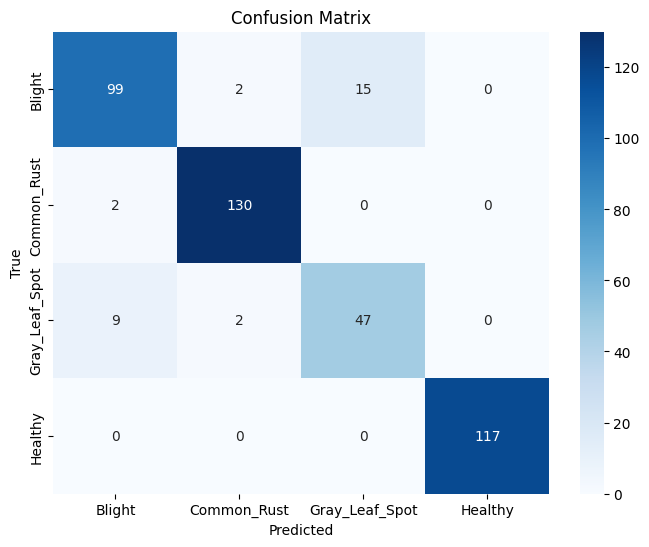

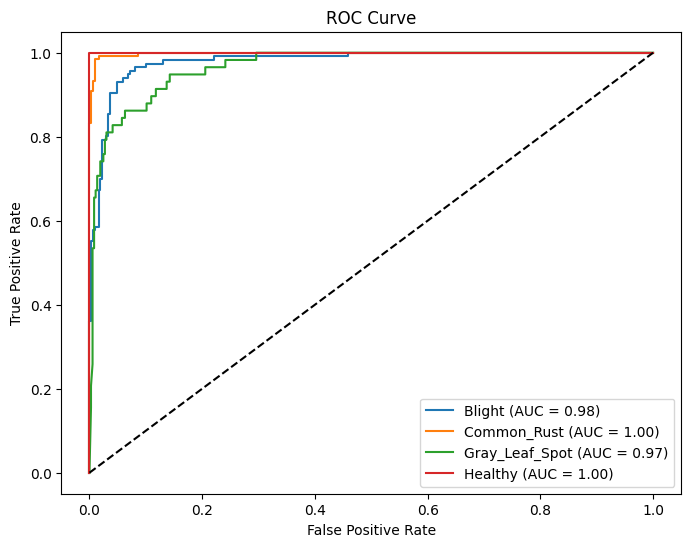

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

# Paths
train_dir = "/content/drive/MyDrive/CornSplit/train"
val_dir = "/content/drive/MyDrive/CornSplit/val"
test_dir = "/content/drive/MyDrive/CornSplit/test"

# Parameters
img_size = (224, 224)
batch_size = 32
epochs = 50

# Data generators
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# Build model using MobileNetV2
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze base model

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.25)(x)
output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs
)

# Evaluate
test_loss, test_acc = model.evaluate(test_generator)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Plot accuracy & loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Predictions
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_labels, yticklabels=class_labels, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ROC Curve (for multiclass)
y_true_bin = label_binarize(y_true, classes=list(range(len(class_labels))))
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(class_labels)):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC
plt.figure(figsize=(8, 6))
for i in range(len(class_labels)):
    plt.plot(fpr[i], tpr[i], label=f"{class_labels[i]} (AUC = {roc_auc[i]:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()


In [ ]:
model.save('/content/drive/MyDrive/mobilenet_models/mobilenet.h5')

# MobileNet with data augmentation

Found 3139 images belonging to 4 classes.
Found 626 images belonging to 4 classes.
Found 423 images belonging to 4 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 68s 616ms/step - accuracy: 0.7217 - loss: 0.7774 - val_accuracy: 0.8914 - val_loss: 0.2642
Epoch 2/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 54s 547ms/step - accuracy: 0.8825 - loss: 0.3057 - val_accuracy: 0.8898 - val_loss: 0.2295
Epoch 3/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 53s 533ms/step - accuracy: 0.9114 - loss: 0.2307 - val_accuracy: 0.9058 - val_loss: 0.2238
Epoch 4/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 53s 537ms/step - accuracy: 0.8981 - loss: 0.2478 - val_accuracy: 0.9265 - val_loss: 0.1873
Epoch 5/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 53s 535ms/step - accuracy: 0.9157 - loss: 0.2268 - val_accuracy: 0.9201 - val_loss: 0.1899
Epoch 6/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 82s 537ms/step - accuracy: 0.9218 - loss: 0.2033 - val_accuracy: 0.9313 - val_loss: 0.1812
Epoch 7/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 53s 539ms/step - accuracy: 0.9176 - loss: 0.1986 - val_accuracy: 0.9313 - val_loss: 0.1726
Epoch 8/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 54s 542ms/step - accuracy: 0.9131 - loss: 0.2066 - val_accu

14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 276ms/step - accuracy: 0.9266 - loss: 0.2035

Test Accuracy: 0.9385
Test Loss: 0.1677


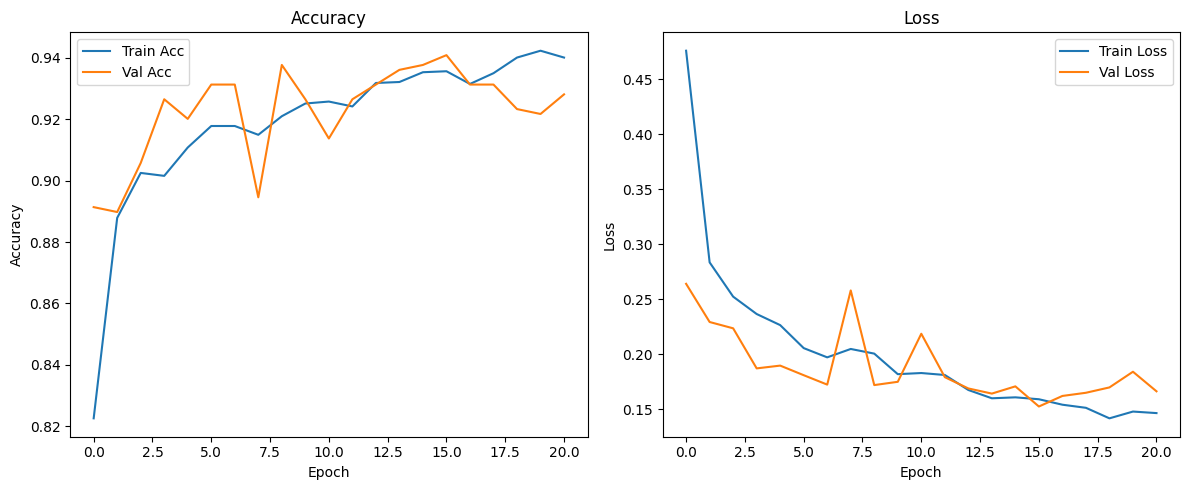

14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 330ms/step

Classification Report:
                precision    recall  f1-score   support

        Blight       0.90      0.91      0.91       116
   Common_Rust       0.96      0.99      0.97       132
Gray_Leaf_Spot       0.84      0.74      0.79        58
       Healthy       1.00      1.00      1.00       117

      accuracy                           0.94       423
     macro avg       0.92      0.91      0.92       423
  weighted avg       0.94      0.94      0.94       423



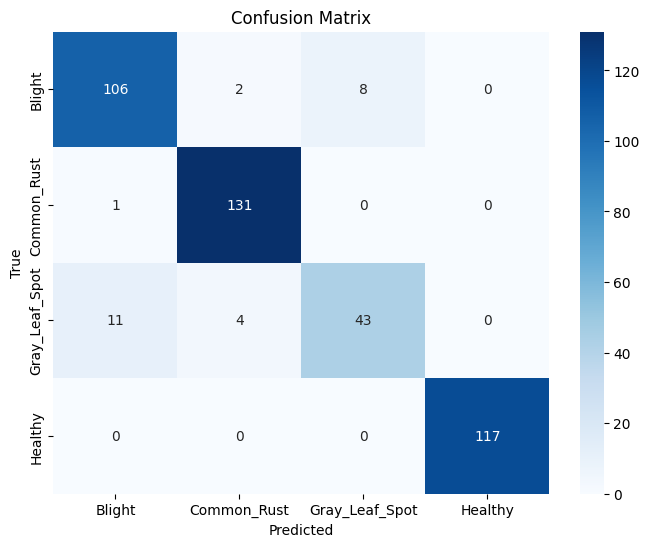

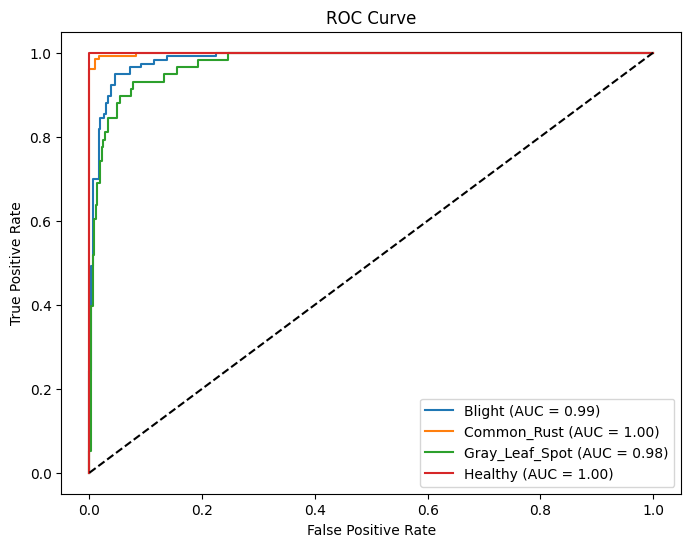

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Paths
train_dir = "/content/drive/MyDrive/CornSplit/train"
val_dir = "/content/drive/MyDrive/CornSplit/val"
test_dir = "/content/drive/MyDrive/CornSplit/test"

# Parameters
img_size = (224, 224)
batch_size = 32
epochs = 50

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# Build model using MobileNetV2
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze base model

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.25)(x)
output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    callbacks=[early_stop]
)
model.save('/content/drive/MyDrive/mobilenet_models/mobilenet_augmented.h5')
# Evaluate
test_loss, test_acc = model.evaluate(test_generator)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Plot accuracy & loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Predictions
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_labels, yticklabels=class_labels, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ROC Curve (for multiclass)
y_true_bin = label_binarize(y_true, classes=list(range(len(class_labels))))
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(class_labels)):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC
plt.figure(figsize=(8, 6))
for i in range(len(class_labels)):
    plt.plot(fpr[i], tpr[i], label=f"{class_labels[i]} (AUC = {roc_auc[i]:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()


# MobileNet with data augmentation + balance class

Found 3139 images belonging to 4 classes.
Found 626 images belonging to 4 classes.
Found 423 images belonging to 4 classes.
Class Weights: {0: np.float64(0.9135622817229336), 1: np.float64(0.8015832482124617), 2: np.float64(1.825), 3: np.float64(0.9009758897818599)}


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 74s 653ms/step - accuracy: 0.6874 - loss: 0.8912 - val_accuracy: 0.8978 - val_loss: 0.2599
Epoch 2/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 71s 582ms/step - accuracy: 0.8468 - loss: 0.4094 - val_accuracy: 0.8866 - val_loss: 0.2708
Epoch 3/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 57s 577ms/step - accuracy: 0.8796 - loss: 0.3197 - val_accuracy: 0.8978 - val_loss: 0.2360
Epoch 4/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 58s 584ms/step - accuracy: 0.8878 - loss: 0.3160 - val_accuracy: 0.8882 - val_loss: 0.2451
Epoch 5/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 58s 582ms/step - accuracy: 0.9021 - loss: 0.2712 - val_accuracy: 0.9073 - val_loss: 0.2063
Epoch 6/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 58s 590ms/step - accuracy: 0.8797 - loss: 0.3226 - val_accuracy: 0.9217 - val_loss: 0.1860
Epoch 7/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 58s 586ms/step - accuracy: 0.8953 - loss: 0.2979 - val_accuracy: 0.8930 - val_loss: 0.2362
Epoch 8/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 84s 605ms/step - accuracy: 0.8998 - loss: 0.2704 - val_accu

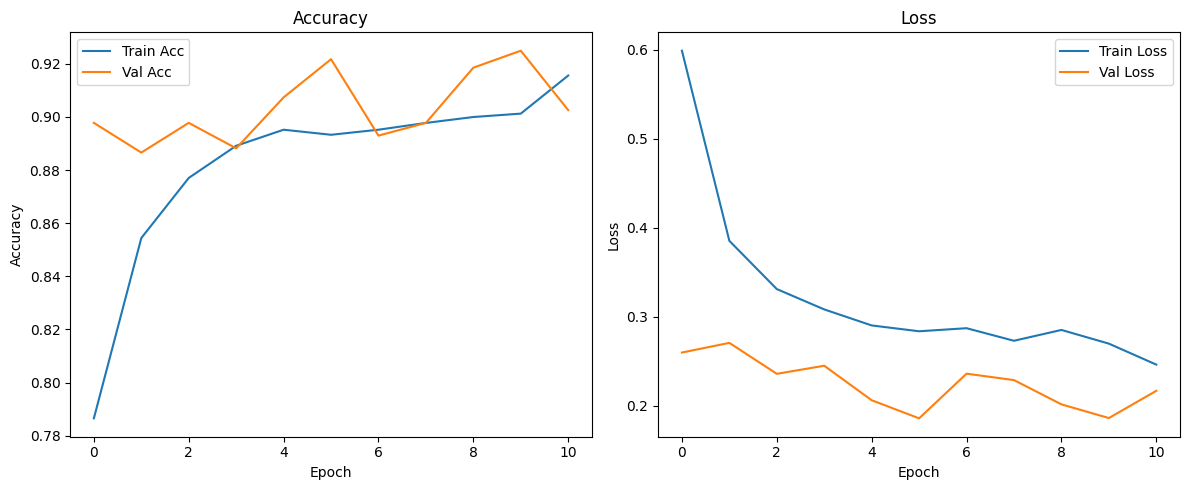

14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 345ms/step

Classification Report:
                precision    recall  f1-score   support

        Blight       0.92      0.86      0.89       116
   Common_Rust       0.96      0.98      0.97       132
Gray_Leaf_Spot       0.79      0.86      0.83        58
       Healthy       1.00      1.00      1.00       117

      accuracy                           0.94       423
     macro avg       0.92      0.93      0.92       423
  weighted avg       0.94      0.94      0.94       423



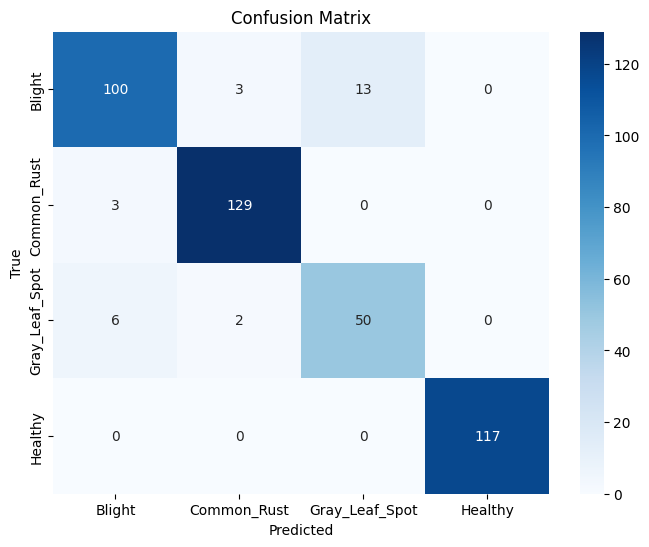

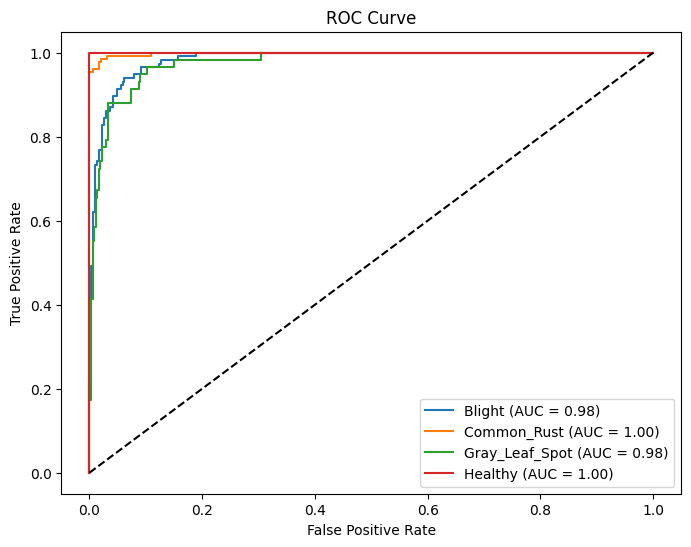

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.utils import class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Paths
train_dir = "/content/drive/MyDrive/CornSplit/train"
val_dir = "/content/drive/MyDrive/CornSplit/val"
test_dir = "/content/drive/MyDrive/CornSplit/test"

# Parameters
img_size = (224, 224)
batch_size = 32
epochs = 50

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# Compute class weights
train_labels = train_generator.classes
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weights_dict)

# Build model using MobileNetV2
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze base model

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    callbacks=[early_stop],
    class_weight=class_weights_dict
)

# Evaluate
test_loss, test_acc = model.evaluate(test_generator)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Plot accuracy & loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Predictions
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_labels, yticklabels=class_labels, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ROC Curve (for multiclass)
y_true_bin = label_binarize(y_true, classes=list(range(len(class_labels))))
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(class_labels)):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC
plt.figure(figsize=(8, 6))
for i in range(len(class_labels)):
    plt.plot(fpr[i], tpr[i], label=f"{class_labels[i]} (AUC = {roc_auc[i]:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()


Found 3139 images belonging to 4 classes.
Found 626 images belonging to 4 classes.
Found 423 images belonging to 4 classes.
Class Weights: {0: np.float64(0.9135622817229336), 1: np.float64(0.8015832482124617), 2: np.float64(1.825), 3: np.float64(0.9009758897818599)}


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 76s 664ms/step - accuracy: 0.6990 - loss: 0.8180 - val_accuracy: 0.8530 - val_loss: 0.3270
Epoch 2/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 60s 607ms/step - accuracy: 0.8459 - loss: 0.4074 - val_accuracy: 0.9105 - val_loss: 0.2223
Epoch 3/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 57s 577ms/step - accuracy: 0.8791 - loss: 0.3356 - val_accuracy: 0.9058 - val_loss: 0.2151
Epoch 4/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 82s 580ms/step - accuracy: 0.8863 - loss: 0.3164 - val_accuracy: 0.9153 - val_loss: 0.2120
Epoch 5/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 64s 644ms/step - accuracy: 0.8898 - loss: 0.2989 - val_accuracy: 0.9201 - val_loss: 0.1838
Epoch 6/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 61s 612ms/step - accuracy: 0.9128 - loss: 0.2502 - val_accuracy: 0.9265 - val_loss: 0.1976
Epoch 7/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 57s 579ms/step - accuracy: 0.8930 - loss: 0.2722 - val_accuracy: 0.9089 - val_loss: 0.2041
Epoch 8/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 58s 589ms/step - accuracy: 0.9134 - loss: 0.2662 - val_accu

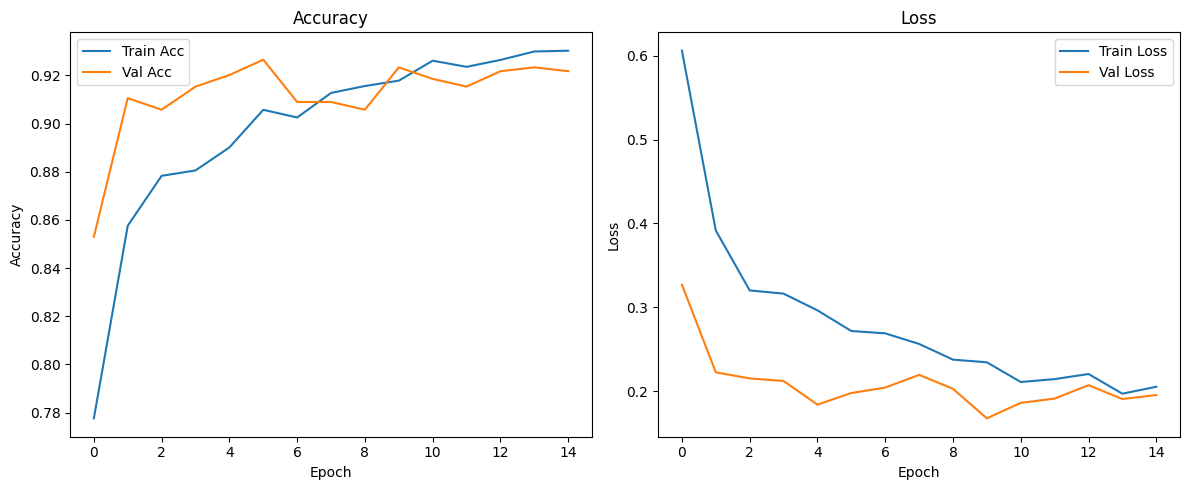

14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 361ms/step

Classification Report:
                precision    recall  f1-score   support

        Blight       0.88      0.91      0.89       116
   Common_Rust       0.97      0.98      0.97       132
Gray_Leaf_Spot       0.83      0.74      0.78        58
       Healthy       1.00      1.00      1.00       117

      accuracy                           0.93       423
     macro avg       0.92      0.91      0.91       423
  weighted avg       0.93      0.93      0.93       423



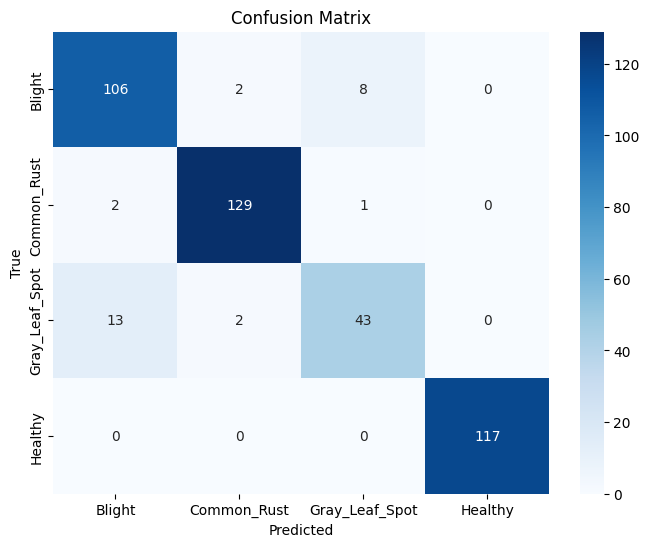

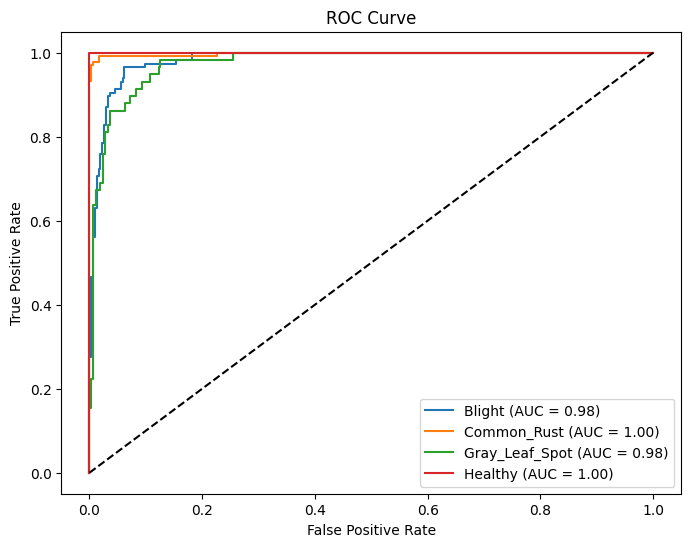

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.utils import class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Paths
train_dir = "/content/drive/MyDrive/CornSplit/train"
val_dir = "/content/drive/MyDrive/CornSplit/val"
test_dir = "/content/drive/MyDrive/CornSplit/test"

# Parameters
img_size = (224, 224)
batch_size = 32
epochs = 50

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# Compute class weights
train_labels = train_generator.classes
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weights_dict)

# Build model using MobileNetV2
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze base model

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    callbacks=[early_stop],
    class_weight=class_weights_dict
)

# Evaluate
test_loss, test_acc = model.evaluate(test_generator)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Plot accuracy & loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Predictions
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_labels, yticklabels=class_labels, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ROC Curve (for multiclass)
y_true_bin = label_binarize(y_true, classes=list(range(len(class_labels))))
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(class_labels)):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC
plt.figure(figsize=(8, 6))
for i in range(len(class_labels)):
    plt.plot(fpr[i], tpr[i], label=f"{class_labels[i]} (AUC = {roc_auc[i]:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()


# # MobileNet with data augmentation + class balance +fine tuning

Found 3139 images belonging to 4 classes.
Found 626 images belonging to 4 classes.
Found 423 images belonging to 4 classes.
Class Weights: {0: np.float64(0.9135622817229336), 1: np.float64(0.8015832482124617), 2: np.float64(1.825), 3: np.float64(0.9009758897818599)}


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 77s 671ms/step - accuracy: 0.6030 - loss: 0.9876 - val_accuracy: 0.8658 - val_loss: 0.3364 - learning_rate: 1.0000e-04
Epoch 2/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 58s 586ms/step - accuracy: 0.8482 - loss: 0.4615 - val_accuracy: 0.9010 - val_loss: 0.2743 - learning_rate: 1.0000e-04
Epoch 3/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 82s 585ms/step - accuracy: 0.8697 - loss: 0.3806 - val_accuracy: 0.9026 - val_loss: 0.2478 - learning_rate: 1.0000e-04
Epoch 4/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 58s 588ms/step - accuracy: 0.8777 - loss: 0.3464 - val_accuracy: 0.9153 - val_loss: 0.2221 - learning_rate: 1.0000e-04
Epoch 5/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 58s 582ms/step - accuracy: 0.8970 - loss: 0.2871 - val_accuracy: 0.8994 - val_loss: 0.2424 - learning_rate: 1.0000e-04
Epoch 6/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 57s 577ms/step - accuracy: 0.8928 - loss: 0.2901 - val_accuracy: 0.9233 - val_loss: 0.2028 - learning_rate: 1.0000e-04
Epoch 7/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 59s 593ms/step - acc

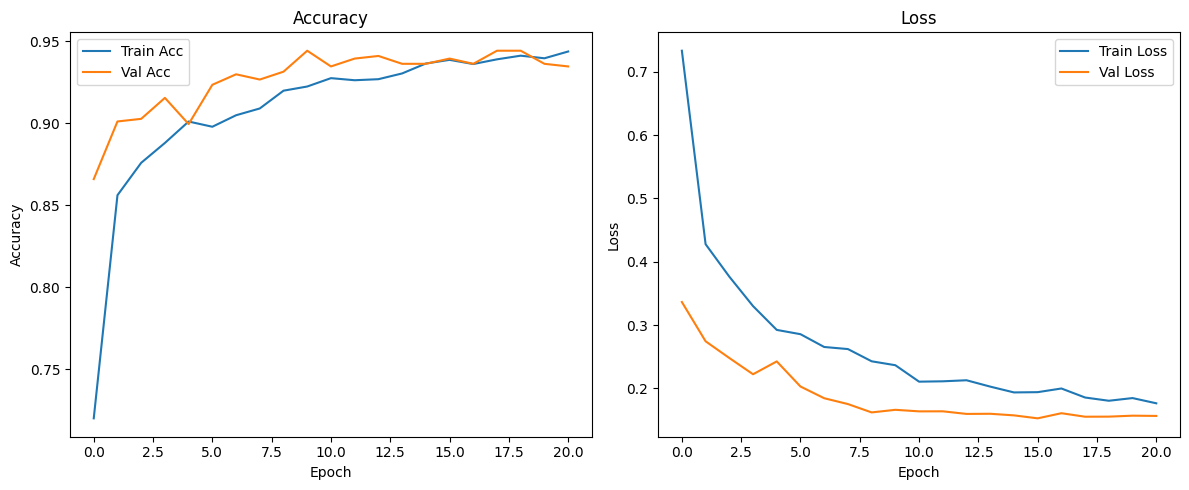

14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 341ms/step

Classification Report:
                precision    recall  f1-score   support

        Blight       0.94      0.89      0.92       116
   Common_Rust       0.97      0.99      0.98       132
Gray_Leaf_Spot       0.82      0.88      0.85        58
       Healthy       1.00      1.00      1.00       117

      accuracy                           0.95       423
     macro avg       0.93      0.94      0.94       423
  weighted avg       0.95      0.95      0.95       423



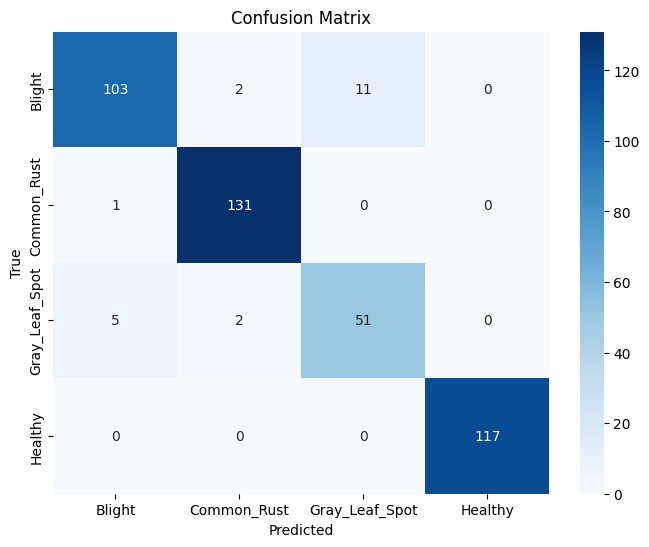

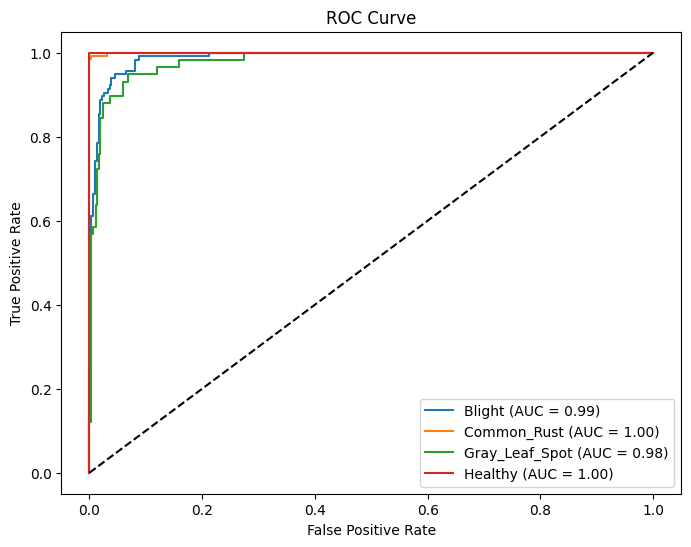

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.utils import class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Paths
train_dir = "/content/drive/MyDrive/CornSplit/train"
val_dir = "/content/drive/MyDrive/CornSplit/val"
test_dir = "/content/drive/MyDrive/CornSplit/test"

# Parameters
img_size = (224, 224)
batch_size = 32
epochs = 50

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# Compute class weights
train_labels = train_generator.classes
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weights_dict)

# Build model using MobileNetV2
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze all layers
for layer in base_model.layers:
    layer.trainable = False

# Unfreeze only the last 4 layers
for layer in base_model.layers[-4:]:
    layer.trainable = True

# Custom classifier head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile
model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-6)

# Train model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights_dict
)

# Evaluate
test_loss, test_acc = model.evaluate(test_generator)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Plot accuracy & loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Predictions
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_labels, yticklabels=class_labels, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ROC Curve (for multiclass)
y_true_bin = label_binarize(y_true, classes=list(range(len(class_labels))))
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(class_labels)):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC
plt.figure(figsize=(8, 6))
for i in range(len(class_labels)):
    plt.plot(fpr[i], tpr[i], label=f"{class_labels[i]} (AUC = {roc_auc[i]:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()


Found 3139 images belonging to 4 classes.
Found 626 images belonging to 4 classes.
Found 423 images belonging to 4 classes.
Class Weights: {0: np.float64(0.9135622817229336), 1: np.float64(0.8015832482124617), 2: np.float64(1.825), 3: np.float64(0.9009758897818599)}


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 85s 742ms/step - accuracy: 0.5724 - loss: 1.1033 - val_accuracy: 0.9010 - val_loss: 0.2801 - learning_rate: 1.0000e-04
Epoch 2/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 73s 691ms/step - accuracy: 0.8523 - loss: 0.4278 - val_accuracy: 0.9058 - val_loss: 0.2480 - learning_rate: 1.0000e-04
Epoch 3/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 61s 612ms/step - accuracy: 0.8782 - loss: 0.3502 - val_accuracy: 0.9121 - val_loss: 0.2237 - learning_rate: 1.0000e-04
Epoch 4/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 63s 637ms/step - accuracy: 0.8903 - loss: 0.3004 - val_accuracy: 0.9169 - val_loss: 0.2131 - learning_rate: 1.0000e-04
Epoch 5/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 60s 607ms/step - accuracy: 0.8845 - loss: 0.3090 - val_accuracy: 0.9153 - val_loss: 0.2053 - learning_rate: 1.0000e-04
Epoch 6/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 59s 595ms/step - accuracy: 0.9068 - loss: 0.2725 - val_accuracy: 0.9201 - val_loss: 0.1960 - learning_rate: 1.0000e-04
Epoch 7/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 59s 590ms/step - acc

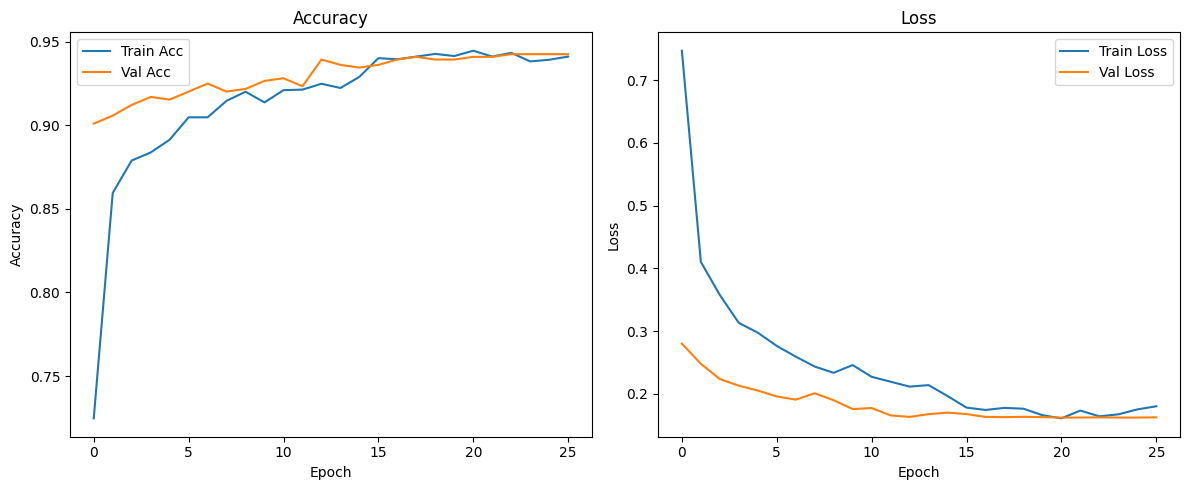

14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 438ms/step

Classification Report:
                precision    recall  f1-score   support

        Blight       0.93      0.91      0.92       116
   Common_Rust       0.98      0.97      0.97       132
Gray_Leaf_Spot       0.84      0.90      0.87        58
       Healthy       1.00      1.00      1.00       117

      accuracy                           0.95       423
     macro avg       0.94      0.94      0.94       423
  weighted avg       0.95      0.95      0.95       423



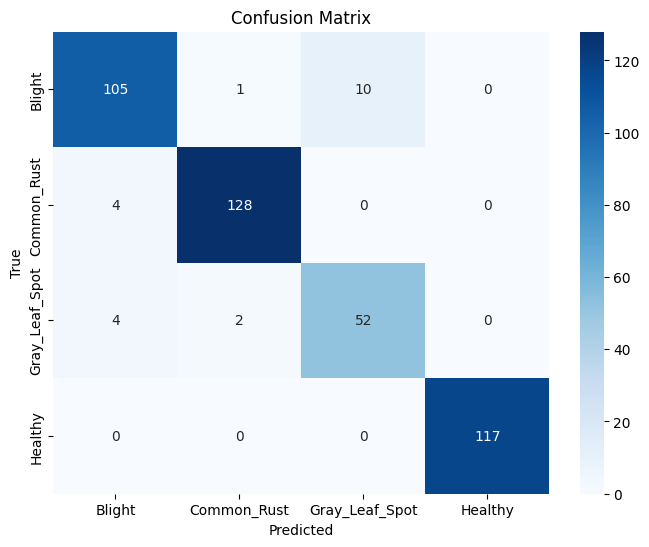

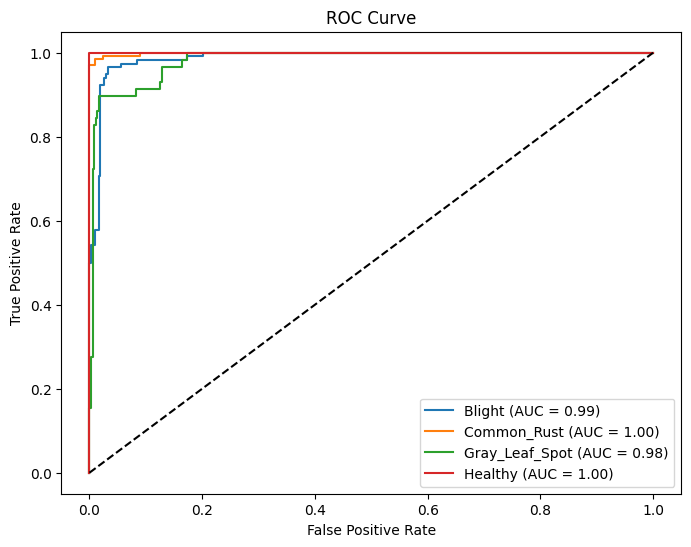

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.utils import class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Paths
train_dir = "/content/drive/MyDrive/CornSplit/train"
val_dir = "/content/drive/MyDrive/CornSplit/val"
test_dir = "/content/drive/MyDrive/CornSplit/test"

# Parameters
img_size = (224, 224)
batch_size = 32
epochs = 50

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# Compute class weights
train_labels = train_generator.classes
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weights_dict)

# Build model using MobileNetV2
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze all layers
for layer in base_model.layers:
    layer.trainable = False

# Unfreeze only the last 4 layers
for layer in base_model.layers[-4:]:
    layer.trainable = True

# Custom classifier head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile
model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-6)

# Train model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights_dict
)

# Evaluate
test_loss, test_acc = model.evaluate(test_generator)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Plot accuracy & loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Predictions
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_labels, yticklabels=class_labels, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ROC Curve (for multiclass)
y_true_bin = label_binarize(y_true, classes=list(range(len(class_labels))))
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(class_labels)):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC
plt.figure(figsize=(8, 6))
for i in range(len(class_labels)):
    plt.plot(fpr[i], tpr[i], label=f"{class_labels[i]} (AUC = {roc_auc[i]:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()


In [ ]:
model.save('/content/drive/MyDrive/mobilenet_models/mobilenet_aug_bal_fined.h5')

Found 3139 images belonging to 4 classes.
Found 626 images belonging to 4 classes.
Found 423 images belonging to 4 classes.
Class Weights: {0: np.float64(0.9135622817229336), 1: np.float64(0.8015832482124617), 2: np.float64(1.825), 3: np.float64(0.9009758897818599)}


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 76s 672ms/step - accuracy: 0.7865 - loss: 0.5660 - val_accuracy: 0.9058 - val_loss: 0.2735 - learning_rate: 0.0010
Epoch 2/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 61s 613ms/step - accuracy: 0.8949 - loss: 0.2775 - val_accuracy: 0.9185 - val_loss: 0.2476 - learning_rate: 0.0010
Epoch 3/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 60s 607ms/step - accuracy: 0.9029 - loss: 0.2637 - val_accuracy: 0.9217 - val_loss: 0.2319 - learning_rate: 0.0010
Epoch 4/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 58s 583ms/step - accuracy: 0.9131 - loss: 0.2329 - val_accuracy: 0.9010 - val_loss: 0.2919 - learning_rate: 0.0010
Epoch 5/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 59s 592ms/step - accuracy: 0.9200 - loss: 0.2243 - val_accuracy: 0.8978 - val_loss: 0.2857 - learning_rate: 0.0010
Epoch 6/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 59s 591ms/step - accuracy: 0.9280 - loss: 0.1945 - val_accuracy: 0.9185 - val_loss: 0.2555 - learning_rate: 3.0000e-04
Epoch 7/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 83s 602ms/step - accuracy: 0.9455 - loss

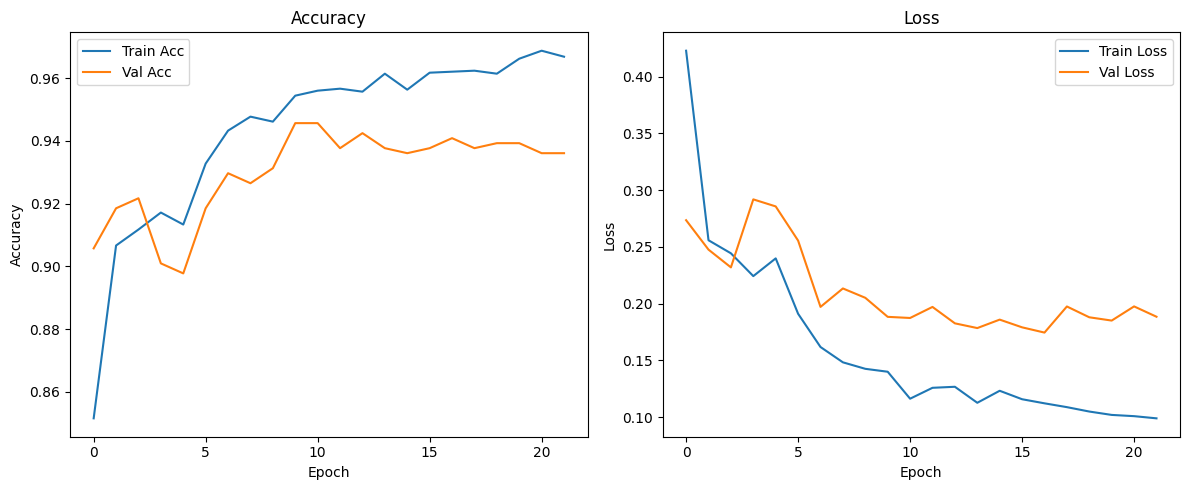

14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 441ms/step

Classification Report:
                precision    recall  f1-score   support

        Blight       0.92      0.91      0.91       116
   Common_Rust       0.96      0.98      0.97       132
Gray_Leaf_Spot       0.84      0.84      0.84        58
       Healthy       1.00      1.00      1.00       117

      accuracy                           0.95       423
     macro avg       0.93      0.93      0.93       423
  weighted avg       0.95      0.95      0.95       423



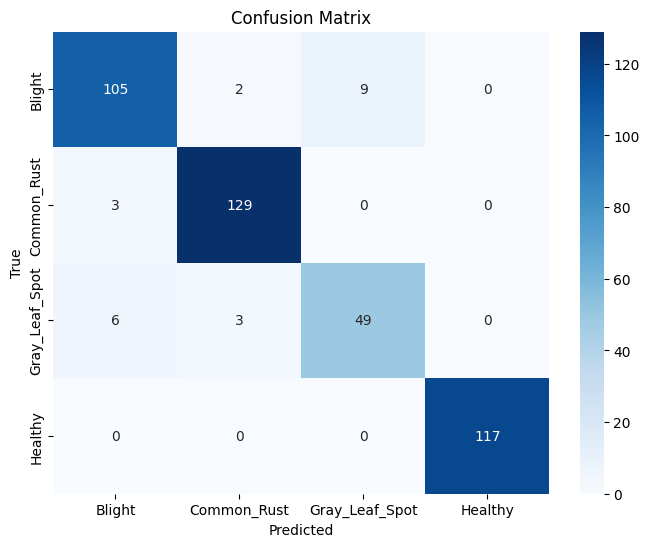

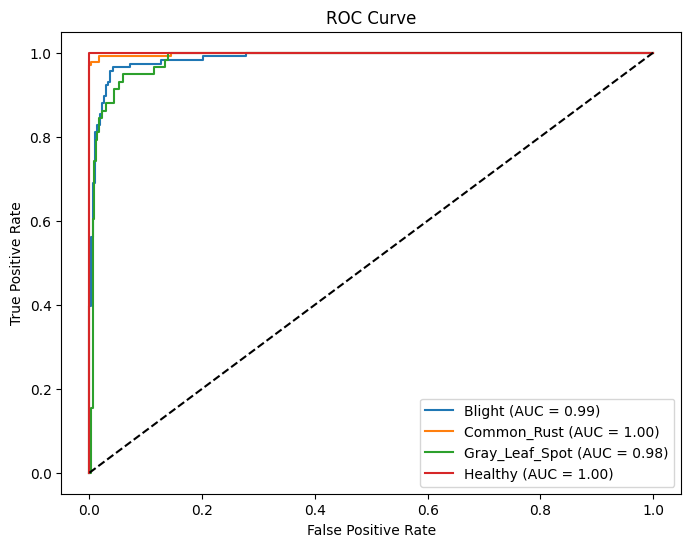

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.utils import class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Paths
train_dir = "/content/drive/MyDrive/CornSplit/train"
val_dir = "/content/drive/MyDrive/CornSplit/val"
test_dir = "/content/drive/MyDrive/CornSplit/test"

# Parameters
img_size = (224, 224)
batch_size = 32
epochs = 50

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# Compute class weights
train_labels = train_generator.classes
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weights_dict)

# Build model using MobileNetV2
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze all layers
for layer in base_model.layers:
    layer.trainable = False

# Unfreeze only the last 4 layers
for layer in base_model.layers[-4:]:
    layer.trainable = True

# Custom classifier head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.25)(x)
output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile
model.compile(optimizer=Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-4)

# Train model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights_dict
)

# Evaluate
test_loss, test_acc = model.evaluate(test_generator)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Plot accuracy & loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Predictions
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_labels, yticklabels=class_labels, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ROC Curve (for multiclass)
y_true_bin = label_binarize(y_true, classes=list(range(len(class_labels))))
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(class_labels)):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC
plt.figure(figsize=(8, 6))
for i in range(len(class_labels)):
    plt.plot(fpr[i], tpr[i], label=f"{class_labels[i]} (AUC = {roc_auc[i]:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()


In [ ]:
model.save('/content/drive/MyDrive/mobilenet_models/mobilenet_aug_bal_fined2.h5')

In [ ]:
model_size_mb = os.path.getsize("/content/drive/MyDrive/mobilenet_models/mobilenet_aug_bal_fined2.h5") / (1024 * 1024)
print(f"Model size: {model_size_mb:.2f} MB")

Model size: 14.17 MB


In [ ]:
model_size_mb = os.path.getsize("/content/drive/MyDrive/mobilenet_models/mobilenet.h5") / (1024 * 1024)
print(f"Model size: {model_size_mb:.2f} MB")

Model size: 11.01 MB


In [ ]:
model_size_mb = os.path.getsize("/content/drive/MyDrive/AfriModels/alexnet_final_model.h5") / (1024 * 1024)
print(f"Model size: {model_size_mb:.2f} MB")

Model size: 667.23 MB


# model size comparision

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.utils import class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


# Build model using MobileNetV2
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze all layers
for layer in base_model.layers:
    layer.trainable = False

# Unfreeze only the last 4 layers
for layer in base_model.layers[-4:]:
    layer.trainable = True

# Custom classifier head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.25)(x)
output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile
model.compile(optimizer=Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])


In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 577,284 (2.20 MB)

 Non-trainable params: 1,845,184 (7.04 MB)

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

# Paths
train_dir = "/content/drive/MyDrive/CornSplit/train"
val_dir = "/content/drive/MyDrive/CornSplit/val"
test_dir = "/content/drive/MyDrive/CornSplit/test"

# Parameters
img_size = (224, 224)
batch_size = 32
epochs = 50

# Data generators
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# Build model using MobileNetV2
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze base model

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.25)(x)
output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


Found 3139 images belonging to 4 classes.
Found 626 images belonging to 4 classes.
Found 423 images belonging to 4 classes.


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

<function matplotlib.pyplot.show(close=None, block=None)>

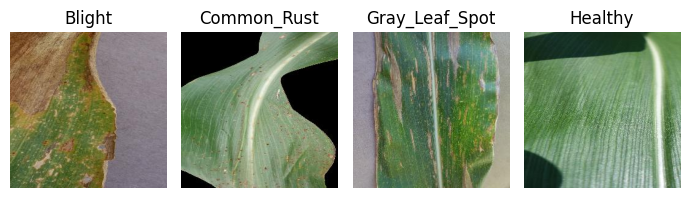

In [ ]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

# Set the main folder path
main_folder = '/content/drive/MyDrive/CornSplit/test'

# Get all subfolders
subfolders = [os.path.join(main_folder, d) for d in os.listdir(main_folder) if os.path.isdir(os.path.join(main_folder, d))]

# Create a plot
fig, axes = plt.subplots(1, len(subfolders), figsize=(7, 4))

for ax, subfolder in zip(axes, subfolders):
    # Get all image files in subfolder
    image_files = [f for f in os.listdir(subfolder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if not image_files:
        ax.set_title("No image")
        ax.axis('off')
        continue

    # Select a random image
    img_path = os.path.join(subfolder, random.choice(image_files))
    image = Image.open(img_path)

    # Show image
    ax.imshow(image)
    ax.set_title(os.path.basename(subfolder))
    ax.axis('off')

plt.tight_layout()
plt.show


In [ ]:
import os
from PIL import Image

# Set the path to your folder (can be a main folder with subfolders or a flat folder)
main_folder = '/content/drive/MyDrive/CornSplit/train'

# Collect all image paths from subfolders
image_paths = []
for root, dirs, files in os.walk(main_folder):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_paths.append(os.path.join(root, file))

# Display resolution of the first five images
print("First five image resolutions:")
for img_path in image_paths[:1]:
    with Image.open(img_path) as img:
        width, height = img.size
        print(f"{os.path.basename(img_path)}: {width}x{height}")


First five image resolutions:
Corn_Blight (1031).JPG: 256x256


Original image shape: (256, 256, 3)
Sample pixel at (0, 0): [ 86 100  83]
First 5 pixels in top row:
 [[ 86 100  83]
 [ 72  89  71]
 [ 75  92  74]
 [ 68  89  70]
 [ 57  78  61]]


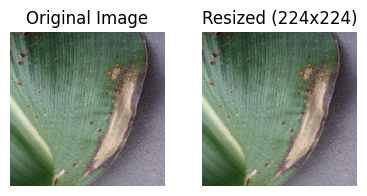

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Load the image
image_path = '/content/drive/MyDrive/CornSplit/test/Blight/Corn_Blight (1009).JPG'
original_image = Image.open(image_path)

# Convert to NumPy array to access pixel values
original_pixels = np.array(original_image)

# Print the shape and some pixel values
print("Original image shape:", original_pixels.shape)
print("Sample pixel at (0, 0):", original_pixels[0, 0])
print("First 5 pixels in top row:\n", original_pixels[0, :5])

# Resize the image to 224x224
resized_image = original_image.resize((224, 224))

# Plot original and resized images side by side
fig, axes = plt.subplots(1, 2, figsize=(4, 2))

axes[0].imshow(original_image)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(resized_image)
axes[1].set_title("Resized (224x224)")
axes[1].axis('off')

plt.tight_layout()
plt.show()
